In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
import re
from collections import deque
import datetime
import config.config as conf

## 1. 파일호출

In [2]:
with open(f'{conf.SNAPSHOT_DIR}/df_da.pkl', 'rb') as f:
    df_da = pickle.load(f)


In [3]:
with open(f'{conf.SNAPSHOT_DIR}/df_body.pkl', 'rb') as f:
    df_body = pickle.load(f)


In [4]:
with open(f'{conf.SNAPSHOT_DIR}/ba_chatgpt_df.pkl', 'rb') as f:
    df = pickle.load(f)


In [5]:
with open(f'{conf.SNAPSHOT_DIR}/df_not_answered.pkl', 'rb') as f:
    df_not_answered = pickle.load(f)
    


In [6]:
df_da['date']   = df_da['q_creationdate'].dt.date
df_da['year']   = df_da['q_creationdate'].dt.year
df_da['month']  = df_da['q_creationdate'].dt.month
df_da['day']    = df_da['q_creationdate'].dt.day

In [7]:
df_body['date'] = df_body['creationdate'].dt.date
df_body['year'] = df_body['creationdate'].dt.year
df_body['month'] = df_body['creationdate'].dt.month
df_body['day'] = df_body['creationdate'].dt.day

In [8]:
df['qna_creation_date'] = pd.to_datetime(df['qna_creation_date'])
df['date'] = df['qna_creation_date'].dt.date
df['year'] = df['qna_creation_date'].dt.year
df['month'] = df['qna_creation_date'].dt.month
df['day'] = df['qna_creation_date'].dt.day


In [9]:
df_not_answered['q_creationdate'] = pd.to_datetime(df_not_answered['q_creationdate'])
df_not_answered['date'] = df_not_answered['q_creationdate'].dt.date
df_not_answered['year'] = df_not_answered['q_creationdate'].dt.year
df_not_answered['month'] = df_not_answered['q_creationdate'].dt.month
df_not_answered['day'] = df_not_answered['q_creationdate'].dt.day

In [10]:
c1 = conf.COLOR_LIST[0][3]
c2 = conf.COLOR_LIST[0][4]

In [11]:
df

,qna_creation_date,posttypeid,cnt,date,year,month,day
0,2013-11-30,1,3657,2013-11-30,2013,11,30
1,2013-11-30,2,5745,2013-11-30,2013,11,30
2,2013-12-01,1,3596,2013-12-01,2013,12,1
3,2013-12-01,2,5391,2013-12-01,2013,12,1
4,2013-12-02,1,6565,2013-12-02,2013,12,2
...,...,...,...,...,...,...,...
8033,2024-11-28,2,1180,2024-11-28,2024,11,28
8034,2024-11-29,1,878,2024-11-29,2024,11,29
8035,2024-11-29,2,1147,2024-11-29,2024,11,29
8036,2024-11-30,1,539,2024-11-30,2024,11,30


In [12]:
df_for_tot = df.groupby(['date'])['cnt'].sum()

## 2. POST

### Number of Questions and Answers over time

In [13]:
df_qna_num = df_body.groupby(['date', 'posttypeid']).count()[['id']].reset_index()

In [14]:
df_qna_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15932 entries, 0 to 15931
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        15932 non-null  object
 1   posttypeid  15932 non-null  object
 2   id          15932 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 373.5+ KB


In [15]:
def get_lastdate_of_month(df, col, month):
    dates = pd.to_datetime(df[col])
    dates_in_month = dates[dates.dt.month == month]

    if dates_in_month.empty:
        return []

    month_end_dates = (
        dates_in_month
        .groupby(dates_in_month.dt.to_period("M"))
        .max()
        .dt.date
        .unique()
        .tolist()
    )

    return sorted(month_end_dates)


In [16]:
major_xticks = get_lastdate_of_month(df_qna_num, 'date', 11)

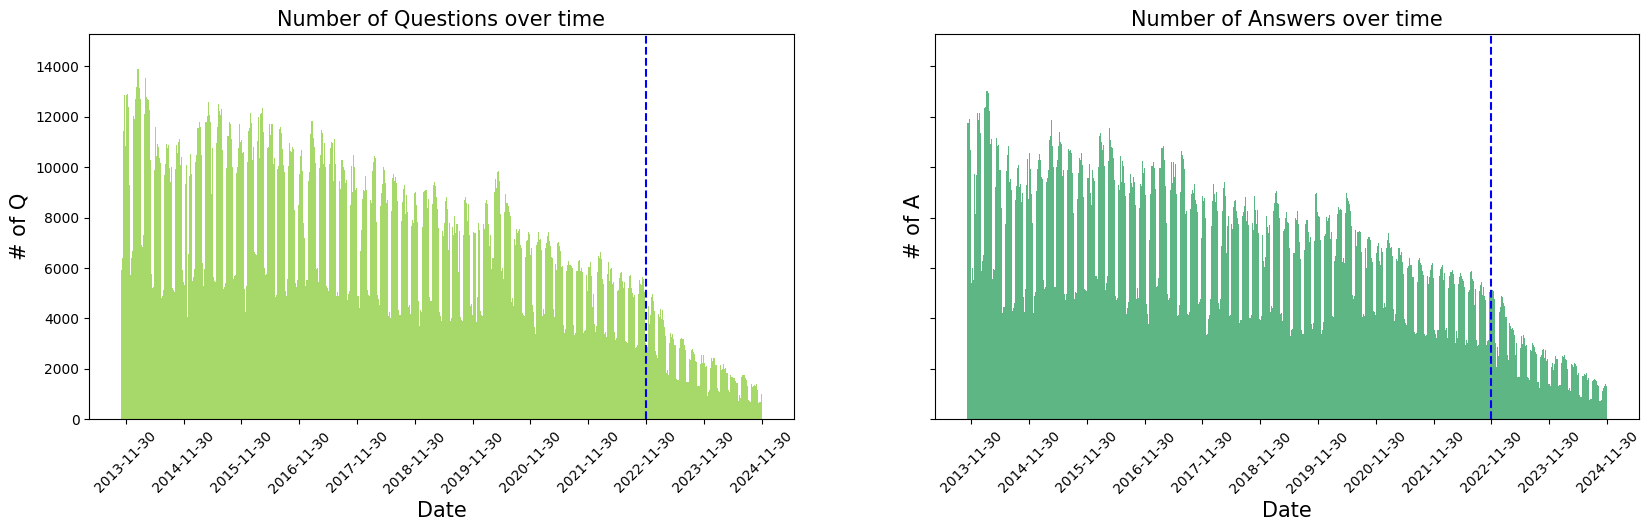

In [17]:
sharey = True ## 또는 sharey=False
sharex = True ## 또는 sharex=False

fig, axs = plt.subplots(1, 2, figsize = (20, 5), sharey=sharey, sharex=sharex)

major_xticks = get_lastdate_of_month(df_qna_num, 'date', 11)

axs[0].bar(df_qna_num[df_qna_num['posttypeid'] =='1'].date
        ,  df_qna_num[df_qna_num['posttypeid'] =='1'].id
        ,  color = c1
        ,  width = 1.0, align = 'center'
      ) # hist type

axs[0].set_title('Number of Questions over time', fontsize = 15)
axs[0].set_xlabel('Date', fontsize = 15)
axs[0].set_ylabel('# of Q', fontsize = 15)
axs[0].set_xticks(major_xticks)
# axs[0].set_yticks(yticks)
axs[0].axvline([major_xticks[-3]], # add vertical line
           color = 'blue',
           linestyle = '--',
           linewidth = 1.5)
axs[0].tick_params(axis='x', rotation=45)
# axs[0].yticks(yt)

axs[1].bar(df_qna_num[df_qna_num['posttypeid'] =='2'].date
        ,  df_qna_num[df_qna_num['posttypeid'] =='2'].id
        ,  color = c2
        ,  alpha=0.7
        ,  width = 1.0, align = 'center'
      ) # hist type

axs[1].set_title('Number of Answers over time', fontsize = 15)
axs[1].set_xlabel('Date', fontsize = 15)
axs[1].set_ylabel('# of A', fontsize = 15)
axs[1].set_xticks(major_xticks)
# axs[1].set_yticks(yticks)
axs[1].axvline([major_xticks[-3]], # add vertical line
           color = 'blue',
           linestyle = '--',
           linewidth = 1.5)
axs[1].tick_params(axis='x', rotation=45)

plt.show();


### Volume of question in weekday

In [18]:
df_for_tot_rset = df_for_tot.reset_index()

In [20]:
df_for_tot_rset.head()

,date,cnt
0,2013-11-30,9402
1,2013-12-01,8987
2,2013-12-02,16868
3,2013-12-03,18707
4,2013-12-04,19245


In [21]:
df_for_tot_rset['weekday_nm'] = pd.to_datetime(df_for_tot_rset['date']).dt.day_name()
df_for_tot_rset['weekday'] = pd.to_datetime(df_for_tot_rset['date']).dt.weekday

In [22]:
df_weekday_mean = df_for_tot_rset.groupby(['weekday_nm', 'weekday']).mean([['cnt']]).reset_index()

In [23]:
df_weekday_mean.sort_values(by = 'weekday', inplace=True)

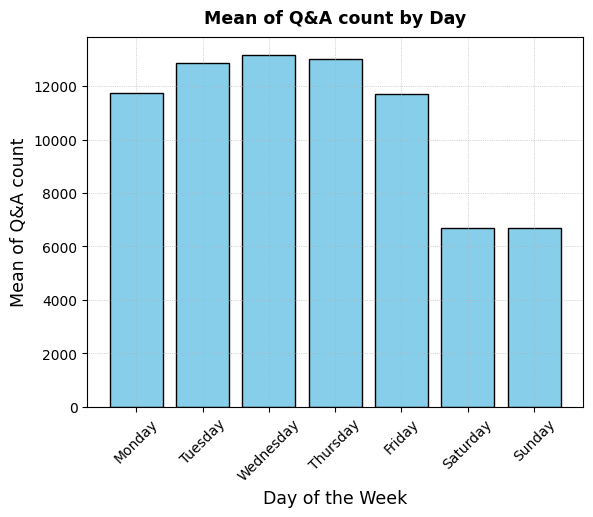

In [24]:
fig, ax = plt.subplots()

ax.bar(df_weekday_mean.weekday_nm
    ,  height = df_weekday_mean['cnt']
    ,  color = 'skyblue'
    ,  edgecolor = 'black'
      ) # hist type

ax.set_title("Mean of Q&A count by Day", # add title
             fontsize = 12.5,
             weight = 'bold',
             pad = 10,
             loc = 'center')
ax.set_xlabel("Day of the Week", # add x-axis label
              fontsize = 12.5)
ax.set_ylabel("Mean of Q&A count", # add y-axis label
              fontsize = 12.5)

label_list = list(df_weekday_mean['weekday_nm'])
tick_values = np.arange(len(label_list))
ax.set_xticks(ticks = tick_values ,labels = label_list, rotation =45)


# fig.text(0.7, 0.76, color = 'red', fontsize = 12.5,  s='Mean: ' + str(round(np.mean(viewcount_df['ViewCount_question']), 2))) #
# fig.text(0.41, 0.77, s='pct_change: ' + str(decrease_2122)) #
# fig.text(0.66, 0.65, s='pct_change: ' + str(decrease_2223)) #

ax.grid(True, linestyle = ':', linewidth = 0.5) # add grid

plt.show();

### Question over Answer

In [25]:
df_pivot = df.pivot_table(index='qna_creation_date', columns='posttypeid', values = 'cnt').reset_index()

In [26]:
df_pivot['q_over_a']=(df_pivot['2']/df_pivot['1'])*100

In [27]:
df_pivot.head()

posttypeid,qna_creation_date,1,2,q_over_a
0,2013-11-30,3657.0,5745.0,157.095980
1,2013-12-01,3596.0,5391.0,149.916574
2,2013-12-02,6565.0,10303.0,156.938309
3,2013-12-03,7208.0,11499.0,159.531077
4,2013-12-04,7431.0,11814.0,158.982640


In [28]:
df_pivot

posttypeid,qna_creation_date,1,2,q_over_a
0,2013-11-30,3657.0,5745.0,157.095980
1,2013-12-01,3596.0,5391.0,149.916574
2,2013-12-02,6565.0,10303.0,156.938309
3,2013-12-03,7208.0,11499.0,159.531077
4,2013-12-04,7431.0,11814.0,158.982640
...,...,...,...,...
4014,2024-11-26,1137.0,1337.0,117.590150
4015,2024-11-27,1041.0,1304.0,125.264169
4016,2024-11-28,1005.0,1180.0,117.412935
4017,2024-11-29,878.0,1147.0,130.637813


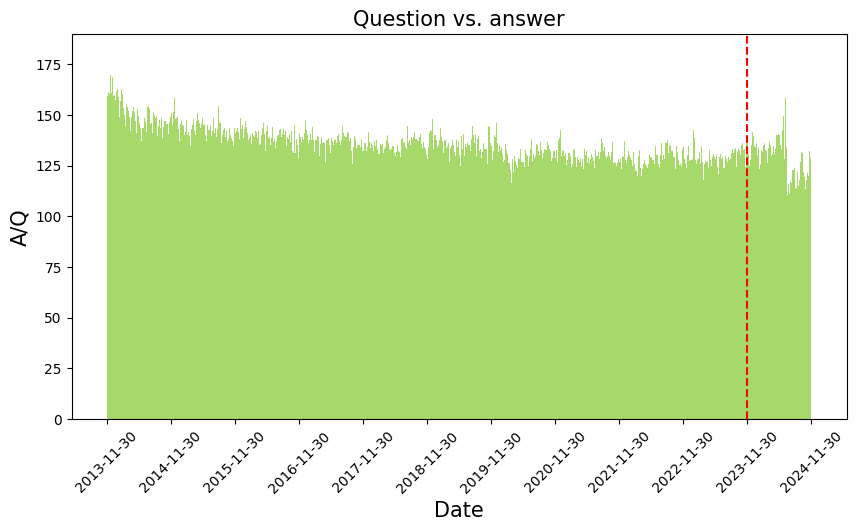

In [29]:
### create a figure with multiple subplots

fig, axs = plt.subplots(figsize = (10, 5))
major_xticks = get_lastdate_of_month(df_pivot, 'qna_creation_date', 11)

axs.bar(df_pivot['qna_creation_date']
        ,  df_pivot['q_over_a']
        ,  color = c1
        ,  width = 1.0, align = 'center'
        # ,  edgecolor = 'black'
      ) # hist type
axs.set_title('Question vs. answer', fontsize = 15)
axs.set_xlabel('Date', fontsize = 15)
axs.set_ylabel('A/Q', fontsize = 15)
axs.set_xticks(major_xticks)
axs.axvline(major_xticks[-2], # add vertical line
           color = 'red',
           linestyle = '--',
           linewidth = 1.5)
axs.tick_params(axis='x', rotation=45)


plt.show();

### Question not Answered

In [33]:
df_not_answeredviz = df_not_answered[['q_id', 'q_creationdate', 'a_id']].copy()

In [34]:
df_not_answered.head()

,q_id,q_creationdate,a_id,date,year,month,day
0,71564856,2022-03-21 22:25:50.703,71565333.0,2022-03-21,2022,3,21
1,77205420,2023-09-30 01:50:31.227,77208467.0,2023-09-30,2023,9,30
2,77205420,2023-09-30 01:50:31.227,77205466.0,2023-09-30,2023,9,30
3,78545172,2024-05-28 15:41:45.837,78545260.0,2024-05-28,2024,5,28
4,67520513,2021-05-13 13:56:39.080,NaN,2021-05-13,2021,5,13


In [35]:
df_not_answeredviz['dt'] = pd.to_datetime(df_not_answeredviz['q_creationdate']).dt.date

In [36]:
df_tot_q = df_not_answeredviz.groupby('dt').count()[['q_id']].reset_index()

In [37]:
df_not_a = df_not_answeredviz[df_not_answeredviz['a_id'].isna()].groupby('dt').count()[['q_id']].reset_index()

In [38]:
df_totq_nota = pd.merge(df_tot_q, df_not_a, on ='dt', how='left')

In [39]:
df_totq_nota.columns = ['dt', 'totq', 'nota']

In [40]:
df_totq_nota['nota_rate'] = np.round(df_totq_nota['nota']/df_totq_nota['totq']*100, 3)
df_totq_nota['a_rate'] = 100- df_totq_nota['nota_rate']

In [41]:
df_totq_nota

,dt,totq,nota,nota_rate,a_rate
0,2020-11-01,4096,491,11.987,88.013
1,2020-11-02,6360,883,13.884,86.116
2,2020-11-03,6823,855,12.531,87.469
3,2020-11-04,6712,881,13.126,86.874
4,2020-11-05,6894,910,13.200,86.800
...,...,...,...,...,...
1486,2024-11-26,1311,514,39.207,60.793
1487,2024-11-27,1166,468,40.137,59.863
1488,2024-11-28,1162,419,36.059,63.941
1489,2024-11-29,1002,376,37.525,62.475


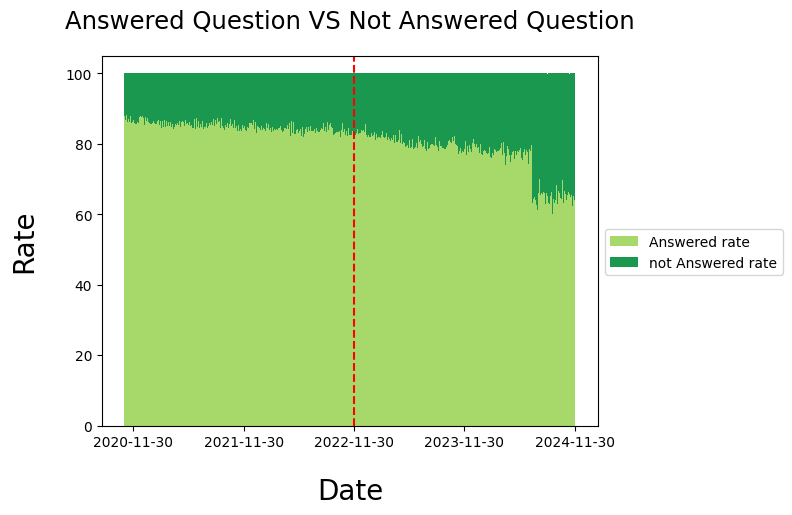

In [42]:
fig, ax = plt.subplots()

ax.bar(df_totq_nota['dt'], df_totq_nota['a_rate'], color=c1, label = 'Answered rate', align='center', width=1.0)
ax.bar(df_totq_nota['dt'], df_totq_nota['nota_rate'], bottom = df_totq_nota['a_rate'], color = c2, label = 'not Answered rate', align='center', width=1.0)

ax.set_xlabel('Date', fontsize = 20, labelpad = 20)
ax.set_ylabel('Rate', fontsize = 20, labelpad = 20)
ax.set_title('Answered Question VS Not Answered Question', fontsize = 17.5, pad = 20)
major_xticks = get_lastdate_of_month(df_totq_nota, 'dt', 11) 
ax.set_xticks(major_xticks)
# ax.tick_params(axis = 'both', labelsize = 17.5)

ax.legend( title_fontsize = 10, fontsize = 10,
          bbox_to_anchor = (1, 0.55))


ax.axvline([major_xticks[-3]], # add vertical line
           color = 'red',
           linestyle = '--',
           linewidth = 1.5)

### Answer Count line plot

In [43]:
df_answered_cnt = df_not_answered.groupby(['q_creationdate', 'q_id']).count()[['a_id']].reset_index()

In [44]:
df_answered_cnt['date'] = pd.to_datetime(df_answered_cnt['q_creationdate']).dt.date.astype('str')

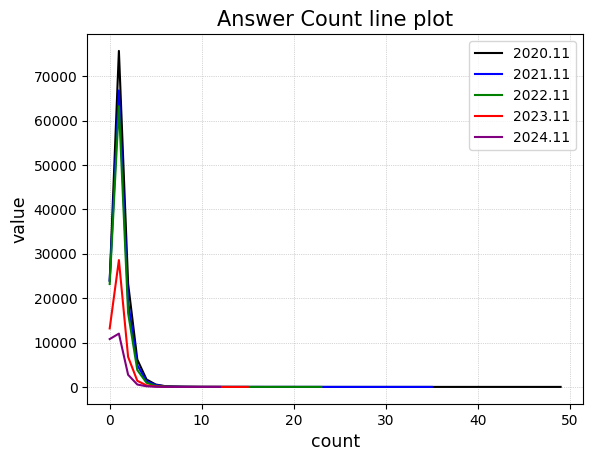

In [45]:
fig, ax = plt.subplots()

ax.plot(df_answered_cnt.loc[(df_answered_cnt['date']>= '2020-11-01')&(df_answered_cnt['date']<= '2020-11-30'), 'a_id'].value_counts().to_frame()['count'].sort_index(), # specify data
        color = 'black',
        label = '2020.11'
) 

ax.plot(df_answered_cnt.loc[(df_answered_cnt['date']>= '2021-11-01')&(df_answered_cnt['date']<= '2021-11-30'), 'a_id'].value_counts().to_frame()['count'].sort_index(), # specify data
        color = 'blue',
        label = '2021.11'
# label = ['question', 'answer']
) # create legened labels

ax.plot(df_answered_cnt.loc[(df_answered_cnt['date']>= '2022-11-01')&(df_answered_cnt['date']<= '2022-11-30'), 'a_id'].value_counts().to_frame()['count'].sort_index(), # specify data
        color = 'green',
         label = '2022.11'
        # label = ['question', 'answer']
        ) # create legened labels

ax.plot(df_answered_cnt.loc[(df_answered_cnt['date']>= '2023-11-01')&(df_answered_cnt['date']<= '2023-11-30'), 'a_id'].value_counts().to_frame()['count'].sort_index(), # specify data
        color = 'red', # bar color
        label = '2023.11'
        ) # create legened labels


ax.plot(df_answered_cnt.loc[(df_answered_cnt['date']>= '2024-11-01')&(df_answered_cnt['date']<= '2024-11-30'), 'a_id'].value_counts().to_frame()['count'].sort_index(), # specify data
        color = 'purple', # bar color
        label = '2024.11'
        ) # create legened labels





ax.set_title('Answer Count line plot', fontsize = 15) # title
ax.set_xlabel('count', fontsize = 12.5) # x-axis label
ax.set_ylabel('value', fontsize = 12.5) # y-axis label

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();

### Minimun timedelta to get response per Date
* 질문과 첫번째 답 사이 gap 에 대한 time distribution

In [46]:
df_da['qna_diff'] = df_da['a_creationdate'] - df_da['q_creationdate']

In [47]:
df_da_df = df_da.sort_values(by = ['date', 'q_id','qna_diff'], ascending=True).groupby(['date', 'q_id']).head(1)

In [50]:
df_da.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26412720 entries, 0 to 26412719
Data columns (total 33 columns):
 #   Column              Dtype          
---  ------              -----          
 0   q_id                int64          
 1   q_posttypeid        object         
 2   q_acceptedanswerid  float64        
 3   q_parentid          object         
 4   q_creationdate      datetime64[ns] 
 5   q_score             int64          
 6   q_viewcount         int64          
 7   q_owneruserid       int64          
 8   q_title             object         
 9   q_tags              object         
 10  q_answercount       int64          
 11  q_commentcount      int64          
 12  q_favoritecount     object         
 13  q_closeddate        datetime64[ns] 
 14  a_id                int64          
 15  a_posttypeid        object         
 16  a_acceptedanswerid  object         
 17  a_parentid          int64          
 18  a_creationdate      datetime64[ns] 
 19  a_score            

In [51]:
df_da_df['qna_diff_int'] = df_da_df['qna_diff']/ pd.Timedelta(days=1)

In [52]:
df_da_df[['qna_diff', 'qna_diff_int', 'date']]

,qna_diff,qna_diff_int,date
15849889,0 days 00:10:44.283000,0.007457,2013-01-01
20443569,0 days 06:45:52.730000,0.281860,2013-01-01
20539267,0 days 00:02:12.633000,0.001535,2013-01-01
10179124,42 days 20:48:07.300000,42.866751,2013-01-01
15343700,0 days 00:06:00.163000,0.004169,2013-01-01
...,...,...,...
24772112,0 days 04:47:12.316000,0.199448,2024-11-30
25641135,7 days 02:12:32.677000,7.092045,2024-11-30
8349051,0 days 08:20:31.007000,0.347581,2024-11-30
7299913,0 days 01:45:46.613000,0.073456,2024-11-30


In [53]:
df_da_df_dff        = df_da_df[['date','year', 'month', 'day','qna_diff_int']].groupby(['date','year', 'month', 'day']).mean().reset_index()
df_da_df_dff_min    = df_da_df[['date','year', 'month', 'day','qna_diff_int']].groupby(['date','year', 'month', 'day']).min().reset_index()
df_da_df_dff_max    = df_da_df[['date','year', 'month', 'day','qna_diff_int']].groupby(['date','year', 'month', 'day']).max().reset_index()
df_da_df_dff_median = df_da_df[['date','year', 'month', 'day','qna_diff_int']].groupby(['date','year', 'month', 'day']).median().reset_index()


In [54]:
df_da_df_dff.head()

,date,year,month,day,qna_diff_int
0,2013-01-01,2013,1,1,15.181580
1,2013-01-02,2013,1,2,17.438763
2,2013-01-03,2013,1,3,20.960914
3,2013-01-04,2013,1,4,20.723828
4,2013-01-05,2013,1,5,12.979983


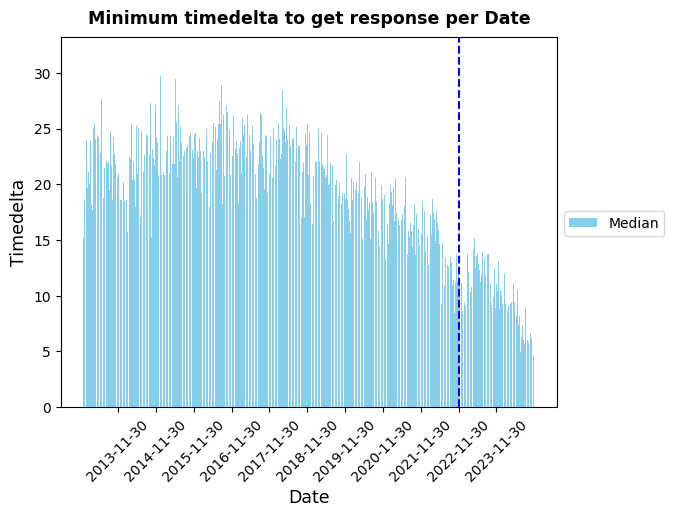

In [ ]:
fig, ax = plt.subplots()

ax.bar(df_da_df_dff.date
    ,  height = df_da_df_dff['qna_diff_int']
    ,  color = 'skyblue'
    ,  label = 'Median'
    , 
    # ,  edgecolor = 'black'
      ) # hist type

ax.set_title("Minimum timedelta to get response per Date", # add title
             fontsize = 12.5,
             weight = 'bold',
             pad = 10,
             loc = 'center')
ax.set_xlabel("Date", # add x-axis label
              fontsize = 12.5)
ax.set_ylabel("Timedelta", # add y-axis label
              fontsize = 12.5)

major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

ax.axvline(['2022-11-30'], # add vertical line
           color = 'blue',
           linestyle = '--',
           linewidth = 1.5)
plt.xticks(rotation=45)



ax.legend( title_fontsize = 10, fontsize = 10,
          bbox_to_anchor = (1, 0.55))

plt.show();

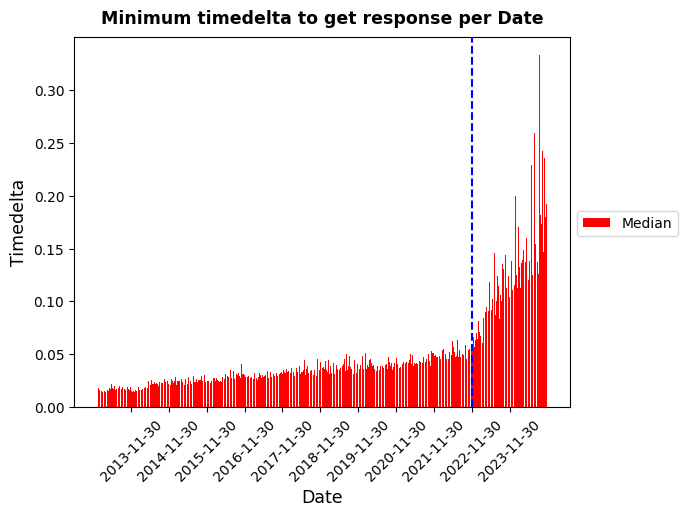

In [56]:
fig, ax = plt.subplots()

ax.bar(df_da_df_dff_median.date
    ,  height = df_da_df_dff_median['qna_diff_int']
    ,  color = 'red'
    ,  label = 'Median'
    # ,  edgecolor = 'black'
      ) # hist type

ax.set_title("Minimum timedelta to get response per Date", # add title
             fontsize = 12.5,
             weight = 'bold',
             pad = 10,
             loc = 'center')
ax.set_xlabel("Date", # add x-axis label
              fontsize = 12.5)
ax.set_ylabel("Timedelta", # add y-axis label
              fontsize = 12.5)

major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

ax.axvline(['2022-11-30'], # add vertical line
           color = 'blue',
           linestyle = '--',
           linewidth = 1.5)
plt.xticks(rotation=45)



ax.legend( title_fontsize = 10, fontsize = 10,
          bbox_to_anchor = (1, 0.55))

plt.show();

### Minimun timedelta to get response per Day in 1 month 
* 질문과 첫번째 답 사이 gap 에 대한 time distribution

In [57]:
df_da_in_month = df_da[df_da['qna_diff'].dt.days <=30]

In [58]:
df_da_in_month_df = df_da_in_month.sort_values(by = ['date', 'q_id','qna_diff'], ascending=True).groupby(['date', 'q_id']).head(1)

In [59]:
df_da_in_month_df['qna_diff_int'] = df_da_in_month_df['qna_diff']/ pd.Timedelta(days=1)

In [60]:
df_da_in_month_df_mean   = df_da_in_month_df[['date','year', 'month', 'day','qna_diff_int']].groupby(['date','year', 'month', 'day']).mean().reset_index()
df_da_in_month_df_min    = df_da_in_month_df[['date','year', 'month', 'day','qna_diff_int']].groupby(['date','year', 'month', 'day']).min().reset_index()
df_da_in_month_df_max    = df_da_in_month_df[['date','year', 'month', 'day','qna_diff_int']].groupby(['date','year', 'month', 'day']).max().reset_index()
df_da_in_month_df_median = df_da_in_month_df[['date','year', 'month', 'day','qna_diff_int']].groupby(['date','year', 'month', 'day']).median().reset_index()


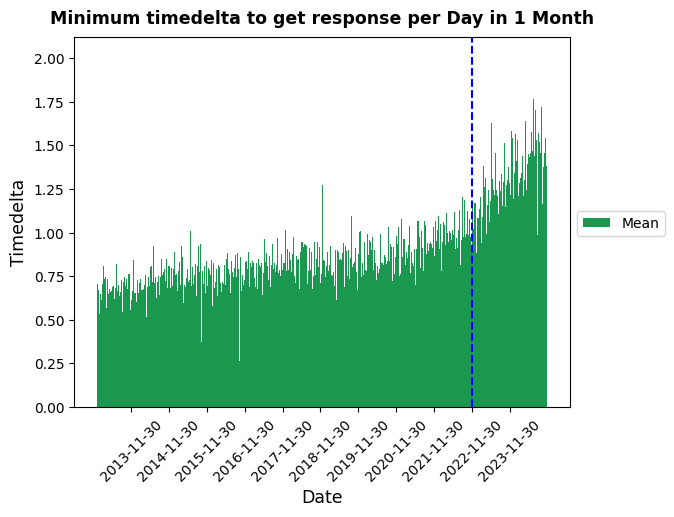

In [81]:
fig, ax = plt.subplots()

ax.bar(df_da_in_month_df_mean.date
    ,  height = df_da_in_month_df_mean['qna_diff_int']
    ,  color = c2
    ,  label = 'Mean'
    ,  width = 1.0, align = 'center'
    # ,  edgecolor = 'black'
      ) # hist type

ax.set_title("Minimum timedelta to get response per Day in 1 Month", # add title
             fontsize = 12.5,
             weight = 'bold',
             pad = 10,
             loc = 'center')
ax.set_xlabel("Date", # add x-axis label
              fontsize = 12.5)
ax.set_ylabel("Timedelta", # add y-axis label
              fontsize = 12.5)

major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

ax.axvline(['2022-11-30'], # add vertical line
           color = 'blue',
           linestyle = '--',
           linewidth = 1.5)
plt.xticks(rotation=45)



ax.legend( title_fontsize = 10, fontsize = 10,
          bbox_to_anchor = (1, 0.55))

plt.show();

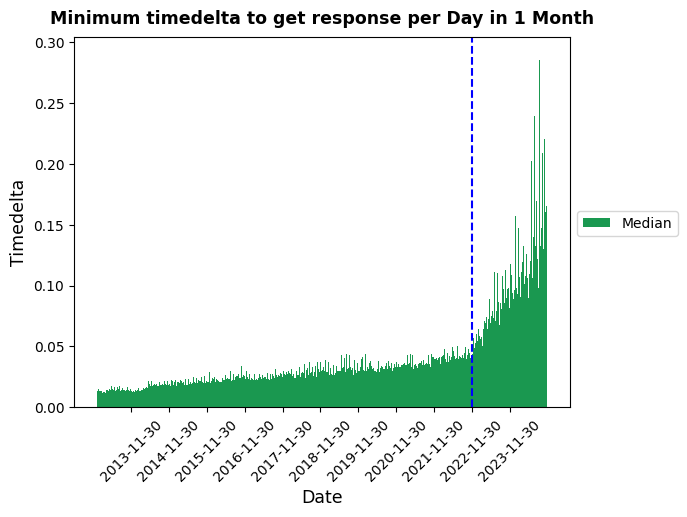

In [80]:
fig, ax = plt.subplots()

ax.bar(df_da_in_month_df_median.date
    ,  height = df_da_in_month_df_median['qna_diff_int']
    ,  color = c2
    ,  label = 'Median'
    ,  width = 1.0, align = 'center'

    # ,  edgecolor = 'black'
      ) # hist type

ax.set_title("Minimum timedelta to get response per Day in 1 Month", # add title
             fontsize = 12.5,
             weight = 'bold',
             pad = 10,
             loc = 'center'
             )
ax.set_xlabel("Date", # add x-axis label
              fontsize = 12.5)
ax.set_ylabel("Timedelta", # add y-axis label
              fontsize = 12.5)

major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

ax.axvline(['2022-11-30'], # add vertical line
           color = 'blue',
           linestyle = '--',
           linewidth = 1.5)
plt.xticks(rotation=45)



ax.legend( title_fontsize = 10, fontsize = 10,
          bbox_to_anchor = (1, 0.55))

plt.show();

### accepted id 기준으로 시각화

In [63]:
df_da_acc = df_da[df_da['q_acceptedanswerid'] == df_da['a_id']].copy()

In [64]:
df_da_acc['qna_diff_int'] = df_da_acc['qna_diff']/ pd.Timedelta(minutes=1)

In [65]:
df_da_acc_df_mean   = df_da_acc[['date','year', 'month', 'day','qna_diff_int']].groupby(['date','year', 'month', 'day']).mean().reset_index()
df_da_acc_df_min    = df_da_acc[['date','year', 'month', 'day','qna_diff_int']].groupby(['date','year', 'month', 'day']).min().reset_index()
df_da_acc_df_max    = df_da_acc[['date','year', 'month', 'day','qna_diff_int']].groupby(['date','year', 'month', 'day']).max().reset_index()
df_da_acc_df_median = df_da_acc[['date','year', 'month', 'day','qna_diff_int']].groupby(['date','year', 'month', 'day']).median().reset_index()


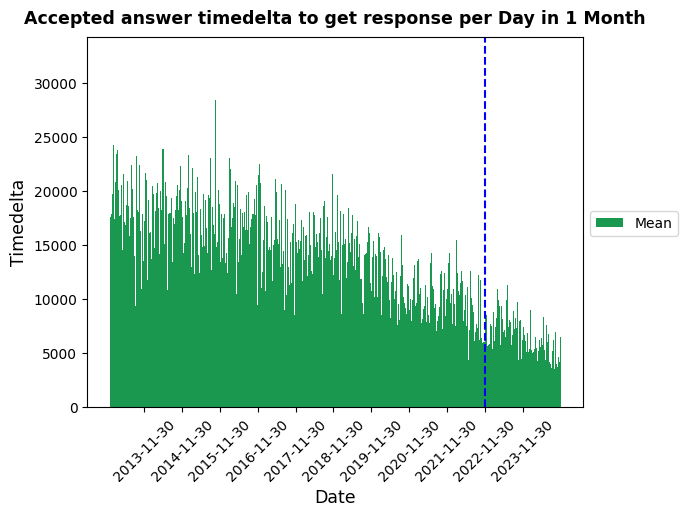

In [82]:
fig, ax = plt.subplots()

ax.bar(df_da_acc_df_mean.date
    ,  height = df_da_acc_df_mean['qna_diff_int']
    ,  color = c2
    ,  label = 'Mean'
    ,  width = 1.0, align = 'center'
    # ,  edgecolor = 'black'
      ) # hist type

ax.set_title("Accepted answer timedelta to get response per Day in 1 Month", # add title
             fontsize = 12.5,
             weight = 'bold',
             pad = 10,
             loc = 'center')
ax.set_xlabel("Date", # add x-axis label
              fontsize = 12.5)
ax.set_ylabel("Timedelta", # add y-axis label
              fontsize = 12.5)

major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

ax.axvline(['2022-11-30'], # add vertical line
           color = 'blue',
           linestyle = '--',
           linewidth = 1.5)
plt.xticks(rotation=45)



ax.legend( title_fontsize = 10, fontsize = 10,
          bbox_to_anchor = (1, 0.55))

plt.show();

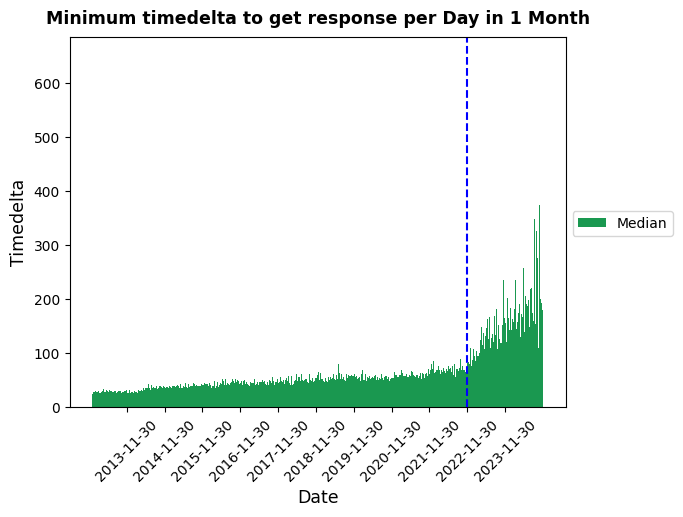

In [84]:
fig, ax = plt.subplots()

ax.bar(df_da_acc_df_median.date
    ,  height = df_da_acc_df_median['qna_diff_int']
    ,  color = c2
    ,  label = 'Median'
    ,  width = 1.0, align = 'center'
    # ,  edgecolor = 'black'
      ) # hist type

ax.set_title("Minimum timedelta to get response per Day in 1 Month", # add title
             fontsize = 12.5,
             weight = 'bold',
             pad = 10,
             loc = 'center')
ax.set_xlabel("Date", # add x-axis label
              fontsize = 12.5)
ax.set_ylabel("Timedelta", # add y-axis label
              fontsize = 12.5)

major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

ax.axvline(['2022-11-30'], # add vertical line
           color = 'blue',
           linestyle = '--',
           linewidth = 1.5)
plt.xticks(rotation=45)



ax.legend( title_fontsize = 10, fontsize = 10,
          bbox_to_anchor = (1, 0.55))

plt.show();

### Distribution of Timedelta

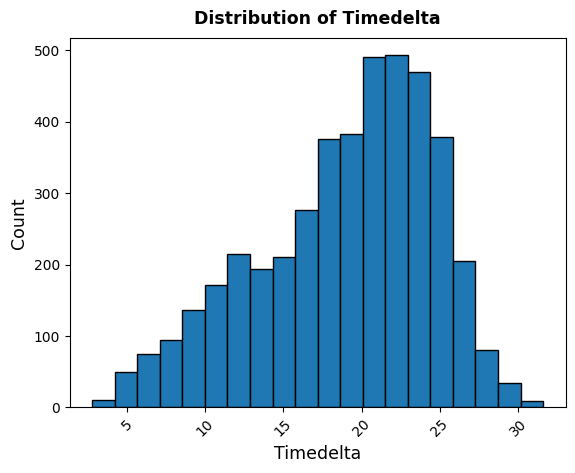

In [68]:
fig, ax = plt.subplots()


# ax.bar(df_date_per_len_max_q.index
#     ,  height = df_date_per_len_max_q['body_len']
#     ,  color = 'green'
#     # ,  edgecolor = 'black'
#       ) # hist type

ax.hist(df_da_df_dff['qna_diff_int'], # specify data
        bins = 20, # number of bins

        edgecolor = 'black', # bar edge color
        histtype = 'bar', # type of histogram
        label = ['Answer Count', 'User Count']) # create legened labels

# ax.bar(df_date_per_len_min_q.index
#     ,  height = df_date_per_len_min_q['body_len']
#     ,  color = 'red'
#     # ,  edgecolor = 'black'
#       ) # hist type

ax.set_title("Distribution of Timedelta", # add title
             fontsize = 12.5,
             weight = 'bold',
             pad = 10,
             loc = 'center')
ax.set_xlabel("Timedelta", # add x-axis label
              fontsize = 12.5)
ax.set_ylabel("Count", # add y-axis label
              fontsize = 12.5)

# major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
#                 ,'2021-11-30', '2022-11-30', '2023-11-30']
# ax.set_xticks(major_xticks)

# ax.axvline(['2022-11-30'], # add vertical line
#            color = 'red',
#            linestyle = '--',
#            linewidth = 1.5)
plt.xticks(rotation=45)



# ax.legend( title_fontsize = 10, fontsize = 10,
#           bbox_to_anchor = (1, 0.55))

plt.show();

### Length of Questions per Date

In [69]:
df_body.groupby(['year', 'month', 'day', 'posttypeid']).mean(['body_len'])

id   owneruserid  answered_yn
year month day posttypeid                                         
2013 11    1   1           1.972805e+07  1.852260e+06     0.956761
               2           1.972810e+07  1.403348e+06     0.000000
               4           1.972889e+07  1.070034e+06     0.000000
               5           1.972888e+07  7.942787e+05     0.000000
           2   1           1.974292e+07  1.941183e+06     0.956607
...                                 ...           ...          ...
2024 11    29  2           7.923709e+07  1.102575e+07     0.000000
           30  1           7.923961e+07  1.403139e+07     0.651757
               2           7.923966e+07  1.062369e+07     0.000000
               4           7.923885e+07  4.632019e+06     0.000000
               5           7.923885e+07  4.632019e+06     0.000000

[15932 rows x 3 columns]

In [70]:
df_date_per_len = df_body.groupby(['date','year', 'month', 'day', 'posttypeid']).mean(['body_len']).reset_index()
df_date_per_len_min = df_body.groupby(['date','year', 'month', 'day', 'posttypeid']).min(['body_len']).reset_index()
df_date_per_len_max = df_body.groupby(['date','year', 'month', 'day', 'posttypeid']).max(['body_len']).reset_index()
df_date_per_len_median = df_body.groupby(['date','year', 'month', 'day', 'posttypeid']).median(['body_len']).reset_index()

In [71]:
df_body.groupby(['date','year', 'month', 'day', 'posttypeid']).max(['body_len'])

id  owneruserid  answered_yn
date       year month day posttypeid                                    
2013-11-01 2013 11    1   1           19747663    7385447.0            1
                          2           19743977    7586085.0            0
                          4           19737228    2462313.0            0
                          5           19737227    2462313.0            0
2013-11-02 2013 11    2   1           19768250    5372587.0            1
...                                        ...          ...          ...
2024-11-29 2024 11    29  2           79238607   28553946.0            0
2024-11-30 2024 11    30  1           79240686   28565911.0            1
                          2           79240674   28564400.0            0
                          4           79238853    4632019.0            0
                          5           79238852    4632019.0            0

[15932 rows x 3 columns]

In [72]:
df_date_per_len_q = df_date_per_len[df_date_per_len['posttypeid'] =='1']
df_date_per_len_q = df_date_per_len_q.set_index('date')
df_date_per_len_a = df_date_per_len[df_date_per_len['posttypeid'] =='2']
df_date_per_len_a = df_date_per_len_a.set_index('date')

In [73]:
df_date_per_len_min_q = df_date_per_len_min[df_date_per_len_min['posttypeid'] =='1']
df_date_per_len_min_q = df_date_per_len_min_q.set_index('date')
df_date_per_len_min_a = df_date_per_len_min[df_date_per_len_min['posttypeid'] =='2']
df_date_per_len_min_a = df_date_per_len_min_a.set_index('date')

In [74]:
df_date_per_len_max_q = df_date_per_len_max[df_date_per_len_max['posttypeid'] =='1']
df_date_per_len_max_q = df_date_per_len_max_q.set_index('date')
df_date_per_len_max_a = df_date_per_len_max[df_date_per_len_max['posttypeid'] =='2']
df_date_per_len_max_a = df_date_per_len_max_a.set_index('date')

In [75]:
df_date_per_len_median_q = df_date_per_len_median[df_date_per_len_median['posttypeid'] =='1']
df_date_per_len_median_q = df_date_per_len_median_q.set_index('date')
df_date_per_len_median_a = df_date_per_len_median[df_date_per_len_median['posttypeid'] =='2']
df_date_per_len_median_a = df_date_per_len_median_a.set_index('date')

KeyError: 'body_len'

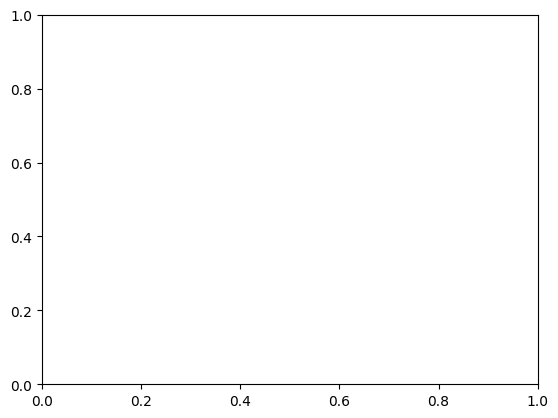

In [76]:
fig, ax = plt.subplots()


# ax.bar(df_date_per_len_max_q.index
#     ,  height = df_date_per_len_max_q['body_len']
#     ,  color = 'green'
#     # ,  edgecolor = 'black'
#       ) # hist type

ax.bar(df_date_per_len_q.index
    ,  height = df_date_per_len_q['body_len']
    ,  color = 'skyblue'
    ,  label = 'Mean'
    # ,  edgecolor = 'black'
      ) # hist type

ax.bar(df_date_per_len_median_q.index
    ,  height = df_date_per_len_median_q['body_len']
    ,  color = 'red'
    ,  label = 'Median'
    # ,  edgecolor = 'black'
      ) # hist type


# ax.bar(df_date_per_len_min_q.index
#     ,  height = df_date_per_len_min_q['body_len']
#     ,  color = 'red'
#     # ,  edgecolor = 'black'
#       ) # hist type

ax.set_title("Length of Questions per Date", # add title
             fontsize = 12.5,
             weight = 'bold',
             pad = 10,
             loc = 'center')
ax.set_xlabel("Date", # add x-axis label
              fontsize = 12.5)
ax.set_ylabel("Length", # add y-axis label
              fontsize = 12.5)

major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

ax.axvline(['2022-11-30'], # add vertical line
           color = 'blue',
           linestyle = '--',
           linewidth = 1.5)
plt.xticks(rotation=45)



ax.legend( title_fontsize = 10, fontsize = 10,
          bbox_to_anchor = (1, 0.55))

plt.show();

In [ ]:
df_date_per_len_diff = (df_date_per_len_max_q['body_len'] - df_date_per_len_min_q['body_len']).to_frame()

In [ ]:
fig, ax = plt.subplots()


ax.bar(df_date_per_len_diff.index
    ,  height = df_date_per_len_diff['body_len']
    ,  color = 'skyblue'
    ,  label = 'Mean'
    # ,  edgecolor = 'black'
      ) # hist type

ax.set_title("Length of Questions per Date", # add title
             fontsize = 12.5,
             weight = 'bold',
             pad = 10,
             loc = 'center')
ax.set_xlabel("Date", # add x-axis label
              fontsize = 12.5)
ax.set_ylabel("Length", # add y-axis label
              fontsize = 12.5)

major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

ax.axvline(['2022-11-30'], # add vertical line
           color = 'red',
           linestyle = '--',
           linewidth = 1.5)
plt.xticks(rotation=45)
plt.show();

### Length of Answers per Date

In [ ]:
fig, ax = plt.subplots()

ax.bar(df_date_per_len_a.index
    ,  height = df_date_per_len_a['body_len']
    ,  color = 'skyblue'
    ,  label = 'Mean'
    # ,  edgecolor = 'black'
      ) # hist type

ax.bar(df_date_per_len_median_a.index
    ,  height = df_date_per_len_median_a['body_len']
    ,  color = 'red'
    ,  label = 'Median'
    # ,  edgecolor = 'black'
      ) # hist type

ax.set_title("Length of Answers per Date", # add title
             fontsize = 12.5,
             weight = 'bold',
             pad = 10,
             loc = 'center')
ax.set_xlabel("Date", # add x-axis label
              fontsize = 12.5)
ax.set_ylabel("Length", # add y-axis label
              fontsize = 12.5)

major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

ax.axvline(['2022-11-30'], # add vertical line
           color = 'blue',
           linestyle = '--',
           linewidth = 1.5)

ax.legend( title_fontsize = 10, fontsize = 10,
          bbox_to_anchor = (1, 0.55))

plt.xticks(rotation=45)
plt.show();

### Answer Length over Question Length per Date

In [ ]:
df_date_per_len_rate = df_date_per_len_a['body_len'].div( df_date_per_len_q['body_len']).to_frame()

In [ ]:
df_date_per_len_rate.head()

In [ ]:
fig, ax = plt.subplots()

ax.bar(df_date_per_len_rate.index
    ,  height = df_date_per_len_rate['body_len']
    ,  color = 'skyblue'
    # ,  edgecolor = 'black'
      ) # hist type

ax.set_title("Answer Length over Question Length per Date", # add title
             fontsize = 12.5,
             weight = 'bold',
             pad = 10,
             loc = 'center')
ax.set_xlabel("Date", # add x-axis label
              fontsize = 12.5)
ax.set_ylabel("A Len/Q Len", # add y-axis label
              fontsize = 12.5)

major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

ax.axvline(['2022-11-30'], # add vertical line
           color = 'red',
           linestyle = '--',
           linewidth = 1.5)
plt.xticks(rotation=45)
plt.show();







### Length of SRC in Questions per Date

In [ ]:
def cleanhtml(raw_html):
  # 1.Source code in python language is hard to understand, so replace all the <code> tag first
  cleantext_1 = re.findall(r'(?<=\<code>)(.*?)(?=<\/code>)', raw_html.replace('\n', '_**_'))
  cleantext_1 = [x.replace('_**_', '\n') for x in cleantext_1]
  # 2. replace html tags
  # <p>
  tag_re = re.compile('<.*?>')
  cleantext_2 = [re.sub(tag_re, '', x) for x in cleantext_1]
  return cleantext_2

In [ ]:
# # apply the function, cleanhtml to the question and body text
# df_body.loc[:, 'prep_body'] = df_body['body'].apply(cleanhtml)
# 15분 걸림
# 전체 데이터셋 
# with open(f'{conf.SNAPSHOT_DIR}/df_body_prep.pkl', 'wb') as f:
#     pickle.dump(df_body, f)
# 파일 불러오기
with open(f'{conf.SNAPSHOT_DIR}/df_body_prep.pkl', 'rb') as f:
    df_body = pickle.load(f)

In [ ]:
df_body['concat_prep_body'] = df_body['prep_body'].apply(lambda x : ''.join(x))

In [ ]:
df_body['src_len'] = df_body['concat_prep_body'].apply(lambda x:len(x))

In [ ]:
len(df_body['id'].unique())
# 43352042

In [ ]:
df_date_per_src_len = df_body.groupby(['date','year', 'month', 'day', 'posttypeid']).mean(['src_len']).reset_index()
df_date_per_src_len_min = df_body.groupby(['date','year', 'month', 'day', 'posttypeid']).min(['src_len']).reset_index()
df_date_per_src_len_max = df_body.groupby(['date','year', 'month', 'day', 'posttypeid']).max(['src_len']).reset_index()
df_date_per_src_len_median = df_body.groupby(['date','year', 'month', 'day', 'posttypeid']).median(['src_len']).reset_index()

In [ ]:
df_date_per_src_len_q = df_date_per_src_len[df_date_per_src_len['posttypeid'] =='1']
df_date_per_src_len_q = df_date_per_src_len_q.set_index('date')
df_date_per_src_len_a = df_date_per_src_len[df_date_per_src_len['posttypeid'] =='2']
df_date_per_src_len_a = df_date_per_src_len_a.set_index('date')

In [ ]:
df_date_per_src_len_median_q = df_date_per_src_len_median[df_date_per_src_len_median['posttypeid'] =='1']
df_date_per_src_len_median_q = df_date_per_src_len_median_q.set_index('date')
df_date_per_src_len_median_a = df_date_per_src_len_median[df_date_per_src_len_median['posttypeid'] =='2']
df_date_per_src_len_median_a = df_date_per_src_len_median_a.set_index('date')

In [ ]:
fig, ax = plt.subplots()

ax.bar(df_date_per_src_len_q.index
    ,  height = df_date_per_src_len_q['src_len']
    ,  color = 'skyblue'
    ,  label = 'Mean'
    # ,  edgecolor = 'black'
      ) # hist type


ax.bar(df_date_per_src_len_median_q.index
    ,  height = df_date_per_src_len_median_q['src_len']
    ,  color = 'red'
    ,  label = 'Median'
    # ,  edgecolor = 'black'
      ) # hist type

ax.set_title("Length of SRC in Questions per Date", # add title
             fontsize = 12.5,
             weight = 'bold',
             pad = 10,
             loc = 'center')
ax.set_xlabel("Date", # add x-axis label
              fontsize = 12.5)
ax.set_ylabel("Length", # add y-axis label
              fontsize = 12.5)

major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

ax.axvline(['2022-11-30'], # add vertical line
           color = 'blue',
           linestyle = '--',
           linewidth = 1.5)

ax.legend( title_fontsize = 10, fontsize = 10,
          bbox_to_anchor = (1, 0.55))


plt.xticks(rotation=45)
plt.show();

### Length  of SRC in Answers per Date

In [ ]:
fig, ax = plt.subplots()

ax.bar(df_date_per_src_len_a.index
    ,  height = df_date_per_src_len_a['src_len']
    ,  color = 'skyblue'
    ,  label = 'Mean'
    # ,  edgecolor = 'black'
      ) # hist type

ax.bar(df_date_per_src_len_median_a.index
    ,  height = df_date_per_src_len_median_a['src_len']
    ,  color = 'red'
    ,  label = 'Median'
    # ,  edgecolor = 'black'
      ) # hist type

ax.set_title("Length  of SRC in Answers per Date", # add title
             fontsize = 12.5,
             weight = 'bold',
             pad = 10,
             loc = 'center')
ax.set_xlabel("Date", # add x-axis label
              fontsize = 12.5)
ax.set_ylabel("Length", # add y-axis label
              fontsize = 12.5)

major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

ax.axvline(['2022-11-30'], # add vertical line
           color = 'blue',
           linestyle = '--',
           linewidth = 1.5)

ax.legend( title_fontsize = 10, fontsize = 10,
          bbox_to_anchor = (1, 0.55))

plt.xticks(rotation=45)
plt.show();

In [ ]:
df_date_per_src_len_rate = df_date_per_src_len_a['src_len'].div( df_date_per_src_len_q['src_len']).to_frame()

In [ ]:
fig, ax = plt.subplots()

ax.bar(df_date_per_src_len_rate.index
    ,  height = df_date_per_src_len_rate['src_len']
    ,  color = 'skyblue'
    # ,  edgecolor = 'black'
      ) # hist type

ax.set_title("Question and Answer Count per Date", # add title
             fontsize = 12.5,
             weight = 'bold',
             pad = 10,
             loc = 'center')
ax.set_xlabel("Date", # add x-axis label
              fontsize = 12.5)
ax.set_ylabel("Count", # add y-axis label
              fontsize = 12.5)

major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

# ax.axvline('2022-11-30', # add vertical line
#            color = 'red',
#            linestyle = '--',
#            linewidth = 1.5)
plt.xticks(rotation=45)
plt.show();

In [ ]:
df_q_a = df_body[(df_body['posttypeid']=='1')&(df_body['answered_yn']==1)]
df_q = df_body[(df_body['posttypeid']=='1')&(df_body['answered_yn']==0)]
# df_body.groupby(['date','year', 'month', 'day', 'posttypeid']).mean(['body_len']).reset_index()

In [ ]:
# df_date_per_src_len = 
df_q_a_m = df_q_a.groupby(['date','year', 'month', 'day']).mean(['src_per_body']).reset_index()
df_q_a_m_median = df_q_a.groupby(['date','year', 'month', 'day']).median(['src_per_body']).reset_index()

df_q_m = df_q.groupby(['date','year', 'month', 'day']).mean(['src_per_body']).reset_index()
df_q_m_median = df_q.groupby(['date','year', 'month', 'day']).median(['src_per_body']).reset_index()

In [ ]:
df_q_m

In [ ]:
# df_q_a_m['src_per_body'].div(df_q_m['src_per_body'])

### SRC length of Answered Questions

In [ ]:
### create a figure with multiple subplots


sharey = True ## 또는 sharey=False
sharex = True ## 또는 sharex=False

fig, axs = plt.subplots(1, 2, figsize = (20, 5), sharey=sharey, sharex=sharex)
# plt.xticks(rotation=45)
major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
yticks = np.arange(200, 2000, 400)
axs[0].bar(df_q_a_m['date']
        ,  df_q_a_m['src_len']
        ,  color = 'skyblue'
        # ,  edgecolor = 'black'
      ) # hist type


axs[0].bar(df_q_a_m_median['date']
        ,  df_q_a_m_median['src_len']
        ,  color = 'red'
        # ,  edgecolor = 'black'
      ) # hist type

axs[0].set_title('SRC length of Answered Questions ', fontsize = 15)
axs[0].set_xlabel('Date', fontsize = 15)
axs[0].set_ylabel('Length', fontsize = 15)
axs[0].set_xticks(major_xticks)
axs[0].set_yticks(yticks)
axs[0].axvline([major_xticks[-2]], # add vertical line
           color = 'blue',
           linestyle = '--',
           linewidth = 1.5)
axs[0].tick_params(axis='x', rotation=45)
# axs[0].yticks(yt)

axs[1].bar(df_q_m['date']
        ,  df_q_m['src_len']
        ,  color = 'lightgreen'
        # ,  edgecolor = 'black'
      ) # hist type
axs[1].bar(df_q_m_median['date']
        ,  df_q_m_median['src_len']
        ,  color = 'red'
        # ,  edgecolor = 'black'
      ) # hist type

axs[1].set_title('SRC length of not Answered Questions ', fontsize = 15)
axs[1].set_xlabel('Date', fontsize = 15)
axs[1].set_ylabel('Length', fontsize = 15)
axs[1].set_xticks(major_xticks)
axs[1].set_yticks(yticks)
axs[1].axvline([major_xticks[-2]], # add vertical line
           color = 'blue',
           linestyle = '--',
           linewidth = 1.5)
axs[1].tick_params(axis='x', rotation=45)

plt.show();

In [ ]:
# fig, ax = plt.subplots()

# ax.bar(df_date_per_src_len_rate.index
#     ,  height = df_q_a_m['src_per_body'].div(df_q_m['src_per_body'])
#     ,  color = 'skyblue'
#     # ,  edgecolor = 'black'
#       ) # hist type

# ax.set_title("Question and Answer Count per Date", # add title
#              fontsize = 12.5,
#              weight = 'bold',
#              pad = 10,
#              loc = 'center')
# ax.set_xlabel("Date", # add x-axis label
#               fontsize = 12.5)
# ax.set_ylabel("Count", # add y-axis label
#               fontsize = 12.5)

# major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
#                 ,'2021-11-30', '2022-11-30', '2023-11-30']
# ax.set_xticks(major_xticks)

# # ax.axvline('2022-11-30', # add vertical line
# #            color = 'red',
# #            linestyle = '--',
# #            linewidth = 1.5)


# ax.legend( title_fontsize = 10, fontsize = 10,
#           bbox_to_anchor = (1, 0.55))

# plt.xticks(rotation=45)
# plt.show();

### Length of Title per Day

In [ ]:
df_body_q = df_body[df_body['posttypeid'] =='1']

In [ ]:
df_body_q['title_len'] = df_body_q['title'].apply(lambda x : len(x))

In [ ]:
df_date_per_t_len         = df_body_q.groupby(['date','year', 'month', 'day']).mean(['title_len']).reset_index()
df_date_per_len_t_min     = df_body_q.groupby(['date','year', 'month', 'day']).min(['title_len']).reset_index()
df_date_per_len_t_max     = df_body_q.groupby(['date','year', 'month', 'day']).max(['title_len']).reset_index()
df_date_per_len_t_median  = df_body_q.groupby(['date','year', 'month', 'day']).median(['title_len']).reset_index()

In [ ]:
fig, ax = plt.subplots()

ax.bar(df_date_per_t_len.date
    ,  height = df_date_per_t_len['title_len']
    ,  color = 'skyblue'
    ,  label = 'mean'
    # ,  edgecolor = 'black'
      ) # hist type


ax.bar(df_date_per_len_t_median.date
    ,  height = df_date_per_len_t_median['title_len']
    ,  color = 'green'
    ,  label = 'median'
    # ,  edgecolor = 'black'
      ) # hist type


ax.set_title("Length of Title per Day", # add title
             fontsize = 12.5,
             weight = 'bold',
             pad = 10,
             loc = 'center')
ax.set_xlabel("Date", # add x-axis label
              fontsize = 12.5)
ax.set_ylabel("Count", # add y-axis label
              fontsize = 12.5)

major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

ax.axvline(['2022-11-30'], # add vertical line
           color = 'red',
           linestyle = '--',
           linewidth = 1.5)

ax.legend( title_fontsize = 10, fontsize = 10,
          bbox_to_anchor = (1, 0.55))

plt.xticks(rotation=45)
plt.show();

## 3. Tag

### Number of Tag per Day

In [ ]:
df_da_q = df_da[['q_id', 'q_creationdate','q_tags']].drop_duplicates()

In [ ]:
df_da_q['year'] = df_da_q['q_creationdate'].dt.year
df_da_q['month'] = df_da_q['q_creationdate'].dt.month
df_da_q['day'] = df_da_q['q_creationdate'].dt.day
df_da_q['date'] = df_da_q['q_creationdate'].dt.date

In [ ]:
df_da_q['q_tags_list'] = df_da_q['q_tags'].apply(lambda x : x.strip().split(' '))

In [ ]:
print(df_da_q[['q_id']].shape)
print(df_da_q[['q_id']].drop_duplicates().shape)

In [ ]:
df_da_q = df_da_q.reset_index(drop=True)

In [ ]:
df_da_q_ex = df_da_q[['q_id', 'q_tags_list']].apply(pd.Series.explode)

In [ ]:
df_da_q_ex['q_tags_list'].value_counts().head(20)

In [ ]:
df_da_q_ex

In [ ]:
df_da_q['q_tagslen'] = df_da_q['q_tags'].apply(lambda x : len(x.strip().split(' ')))

In [ ]:
df_da_q_year = pd.merge(df_da_q[['q_id', 'year']], df_da_q_ex, on = 'q_id')

In [ ]:
df_da_q_year = df_da_q_year.groupby(['year','q_tags_list']).count()['q_id'].reset_index()
#  df_da.sort_values(by = ['date', 'q_id','qna_diff'], ascending=True).groupby(['date', 'q_id']).head(1) > 확인필요 

In [ ]:
df_da_q_year = df_da_q_year.sort_values(by = ['year', 'q_id'], ascending = False).groupby(['year']).head(10)

In [ ]:
df_da_q_year

In [ ]:
### create a figure with multiple subplots


sharey = False ## 또는 sharey=False
sharex = False ## 또는 sharex=False

fig, axs = plt.subplots(2, 5, figsize = (20, 10), sharey=sharey, sharex=sharex)

for x in range(0, 2):
    for y in range(0,5):
        standard_year = 2015
        loop_year = standard_year + (x*5 + y*1)
        axs[x][y].bar( df_da_q_year[df_da_q_year['year'] ==loop_year].q_tags_list
                    ,  df_da_q_year[df_da_q_year['year'] ==loop_year].q_id
                    ,  color = 'skyblue'
                ) # hist type
        axs[x][y].set_title(str(loop_year), # add title
             pad = 10,
             loc = 'center')
        axs[x][y].tick_params(axis='x', rotation=45)


 
plt.suptitle("Top 10 Tags of Questions over 10 years")      
plt.tight_layout()    
plt.show();

In [ ]:
# df_postcnt_per_tag_year

df_postcnt_per_tag_year_melt = df_postcnt_per_tag_year.melt(id_vars = ['year'], value_vars=df_postcnt_per_tag_year.columns[1:])

In [ ]:
# df_da_q_year.sort_values(by = ['year', 'q_id'], ascending = False).groupby(['year']).head(10)
df_postcnt_top10 = df_postcnt_per_tag_year_melt.sort_values(by = ['year', 'value'], ascending=False).groupby(['year']).head(10)

In [ ]:
df_postcnt_top10

In [ ]:
### create a figure with multiple subplots


sharey = False ## 또는 sharey=False
sharex = False ## 또는 sharex=False

fig, axs = plt.subplots(2, 5, figsize = (20, 10), sharey=sharey, sharex=sharex)

for x in range(0, 2):
    for y in range(0,5):
        standard_year = 2014
        loop_year = str(standard_year + (x*5 + y*1))
        axs[x][y].bar( df_postcnt_top10[df_postcnt_top10['year'] ==loop_year].variable
                    ,  df_postcnt_top10[df_postcnt_top10['year'] ==loop_year].value
                    ,  color = 'skyblue'
                ) # hist type
        axs[x][y].set_title(str(loop_year), # add title
             pad = 10,
             loc = 'center')
        axs[x][y].tick_params(axis='x', rotation=45)


 
plt.suptitle("Top 10 Tags of Questions over 10 years")      
plt.tight_layout()    
plt.show();

In [ ]:
df_da_q_per_len         = df_da_q.groupby(['date','year', 'month', 'day']).mean(['q_tagslen']).reset_index()
df_da_q_per_len_min     = df_da_q.groupby(['date','year', 'month', 'day']).min(['q_tagslen']).reset_index()
df_da_q_per_len_max     = df_da_q.groupby(['date','year', 'month', 'day']).max(['q_tagslen']).reset_index()
df_da_q_per_len_median  = df_da_q.groupby(['date','year', 'month', 'day']).median(['q_tagslen']).reset_index()


In [ ]:
df_da_q_year_top50 = pd.merge(df_da_q[['q_id', 'year']], df_da_q_ex, on = 'q_id')
df_da_q_year_top50 = df_da_q_year_top50.groupby(['year','q_tags_list']).count()['q_id'].reset_index()
df_da_q_year_top50 = df_da_q_year_top50.sort_values(by = ['year', 'q_id'], ascending = False).groupby(['year']).head(50)


In [ ]:
df_da_q_year_top50

In [ ]:
df_da_q_year_top50 = df_da_q_year_top50[df_da_q_year_top50['year'].isin([2022, 2023])].sort_values(by = ['q_id'], ascending=False)

In [ ]:
tags_dict = {}
def get_top_50(row):
    tag_nm = row[1]
    if tag_nm in tags_dict : 
        print("key exists!")
    else :
        print("new key!", tag_nm)
        tags_dict[tag_nm] = row[2]

In [ ]:
df_da_q_year_top50.apply(get_top_50, axis = 1)

In [ ]:
tags_dict

In [ ]:
# 전체 데이터셋 
with open(f'{conf.SNAPSHOT_DIR}/top50_tags_in_2022_2023.pkl', 'wb') as f:
    pickle.dump(tags_dict, f)

In [ ]:
fig, ax = plt.subplots()

ax.bar(df_da_q_per_len_median.date
    ,  height = df_da_q_per_len_median['q_tagslen']
    ,  color = 'green'
    ,  label = 'median'
    # ,  edgecolor = 'black'
      ) # hist type


ax.bar(df_da_q_per_len.date
    ,  height = df_da_q_per_len['q_tagslen']
    ,  color = 'skyblue'
    ,  label = 'mean'
    # ,  edgecolor = 'black'
      ) # hist type



ax.set_title("Number of tag per Day", # add title
             fontsize = 12.5,
             weight = 'bold',
             pad = 10,
             loc = 'center')
ax.set_xlabel("Date", # add x-axis label
              fontsize = 12.5)
ax.set_ylabel("Count", # add y-axis label
              fontsize = 12.5)

major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

# ax.axvline('2022-11-30', # add vertical line
#            color = 'red',
#            linestyle = '--',
#            linewidth = 1.5)

ax.legend( title_fontsize = 10, fontsize = 10,
          bbox_to_anchor = (1, 0.55))

plt.xticks(rotation=45)
plt.show();

In [ ]:
df_da_q_per_len_median

### 4. User

In [ ]:
df_user['year'] = df_user['creationdate'].dt.year
df_user['month'] = df_user['creationdate'].dt.month
df_user['day'] = df_user['creationdate'].dt.day
df_user['date'] = df_user['creationdate'].dt.date


In [ ]:
df_user.groupby(['date','year', 'month', 'day']).count()[['id']].reset_index()

In [ ]:
df_user_per_date         = df_user.groupby(['date','year', 'month', 'day']).count()[['id']].reset_index()

In [ ]:
df_user_per_date

In [ ]:
fig, ax = plt.subplots()

ax.bar(df_user_per_date.date
    ,  height = df_user_per_date['id']
    ,  color = 'skyblue'
    ,  label = 'mean'
    # ,  edgecolor = 'black'
      ) # hist type

ax.set_title("Sign up Users per Day", # add title
             fontsize = 12.5,
             weight = 'bold',
             pad = 10,
             loc = 'center')
ax.set_xlabel("Date", # add x-axis label
              fontsize = 12.5)
ax.set_ylabel("Count", # add y-axis label
              fontsize = 12.5)

major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

ax.axvline(['2022-11-30'], # add vertical line
           color = 'red',
           linestyle = '--',
           linewidth = 1.5)

# ax.legend( title_fontsize = 10, fontsize = 10,
#           bbox_to_anchor = (1, 0.55))

plt.xticks(rotation=45)
plt.show();

## 4. User

In [ ]:
df_user

In [ ]:
df_user['date']   = df_user['creationdate'].dt.date

In [ ]:
df_da_q = df_da[['q_id', 'q_owneruserid']].drop_duplicates()
df_da_a = df_da[['a_id', 'a_owneruserid']].drop_duplicates()

In [ ]:
df_da_q_cnt = df_da_q.groupby(['q_owneruserid']).count()[['q_id']]
df_da_a_cnt = df_da_a.groupby(['a_owneruserid']).count()[['a_id']]

In [ ]:
df_user_qna = pd.merge(df_user, df_da_q_cnt, left_on = 'id', right_on = 'q_owneruserid', how= 'left')
df_user_qna = pd.merge(df_user_qna, df_da_a_cnt, left_on = 'id', right_on = 'a_owneruserid', how= 'left')

In [ ]:
df_user_qna.fillna(0, inplace=True)

In [ ]:
df_user_qna

### Question and Answer

In [ ]:
fig_scatter_reg, ax = plt.subplots(figsize = (10, 6))

ax.scatter(df_user_qna['q_id'], df_user_qna['a_id'], color = 'purple', alpha = 0.6)

ax.set_title('Question and Answer')
ax.set_xlabel('Question')
ax.set_ylabel('Answer')


plt.show();

In [ ]:
df_user_qna

In [ ]:
df_user_qna['gpt_af_yn'] = np.where(df_user_qna['date'] >= datetime.date(2022,11,30), 1, 0)

In [ ]:
df_user_qna

In [ ]:
fig_scatter_reg, ax = plt.subplots(figsize = (10, 6))
sns.scatterplot(data = df_user_qna, x = 'q_id', y = 'a_id', hue = 'gpt_af_yn' )

ax.set_title('Question and Answer')
ax.set_xlabel('Question')
ax.set_ylabel('Answer')


plt.show();

In [ ]:
df_user_qna_bf = df_user_qna[(df_user_qna['creationdate'] >= '2021-11-30') &(df_user_qna['creationdate'] < '2022-11-30') ]

In [ ]:
df_user_qna_af = df_user_qna[(df_user_qna['creationdate'] >= '2022-11-30') &(df_user_qna['creationdate'] < '2023-11-30') ]

In [ ]:
fig_scatter_reg, ax = plt.subplots(figsize = (10, 6))
sns.scatterplot(data = df_user_qna_bf, x = 'q_id', y = 'a_id', hue = 'gpt_af_yn' , color = 'purple', alpha = 0.6)

ax.set_title('Question and Answer-bf')
ax.set_xlabel('Question')
ax.set_ylabel('Answer')
ax.set_yscale('log')
ax.set_xscale('log')

plt.show();



In [ ]:
fig_scatter_reg, ax = plt.subplots(figsize = (10, 6))
sns.scatterplot(data = df_user_qna_af, x = 'q_id', y = 'a_id', hue = 'gpt_af_yn' , color = 'purple', alpha = 0.6)

ax.set_title('Question and Answer-af')
ax.set_xlabel('Question')
ax.set_ylabel('Answer')
ax.set_yscale('log')
ax.set_xscale('log')

plt.show();



In [ ]:
df_user_qna_bf

In [ ]:
fig_scatter_reg, axes = plt.subplots(ncols=2, figsize = (20, 10))
sns.scatterplot(data = df_user_qna_bf, x = 'q_id', y = 'a_id', hue = 'gpt_af_yn' , color = 'purple', alpha = 0.6
                , ax = axes[0])

sns.scatterplot(data = df_user_qna_af, x = 'q_id', y = 'a_id', hue = 'gpt_af_yn' , color = 'purple', alpha = 0.6
                , ax = axes[1])


axes[0].set_title('Question and Answer-bf')
axes[0].set_xlabel('Question')
axes[0].set_ylabel('Answer')
axes[0].set_yscale('log')
axes[0].set_xscale('log')


axes[1].set_title('Question and Answer-af')
axes[1].set_xlabel('Question')
axes[1].set_ylabel('Answer')
axes[1].set_yscale('log')
axes[1].set_xscale('log')

plt.show();



무언가 이상한걸 감지함... 
가입 이후  포스트를 작성한 기간이 동일 하지 않음 이슈... 
맞추고 가보자 300일로 

In [ ]:
df_usr_bf = df_user[(df_user['creationdate']>='2021-12-01') & (df_user['creationdate']<='2021-12-31') ]
df_usr_af = df_user[(df_user['creationdate']>='2022-12-01') & (df_user['creationdate']<='2022-12-31') ]

In [ ]:
df_body = df_body[['id', 'creationdate', 'posttypeid', 'owneruserid']]


In [ ]:
df_body = df_body[df_body['posttypeid'].isin(['1', '2'])]

In [ ]:
df_body.columns = ['p_id', 'p_creationdate', 'posttypeid', 'p_owneruserid']

In [ ]:
df_usr_bf_post = pd.merge(df_usr_bf, df_body, left_on = 'id', right_on = 'p_owneruserid', how='left')
df_usr_af_post = pd.merge(df_usr_af, df_body, left_on = 'id', right_on = 'p_owneruserid', how='left')

In [ ]:
df_usr_bf_post['diff_days'] = df_usr_bf_post['p_creationdate'] - df_usr_bf_post['creationdate']
df_usr_af_post['diff_days'] = df_usr_af_post['p_creationdate'] - df_usr_af_post['creationdate']

In [ ]:
df_usr_bf_post = df_usr_bf_post[df_usr_bf_post['diff_days'].dt.days <300]
df_usr_af_post = df_usr_af_post[df_usr_af_post['diff_days'].dt.days <300]

In [ ]:
df_usr_bf_post = df_usr_bf_post.groupby(['id', 'posttypeid']).count()['p_id'].reset_index()
df_usr_af_post = df_usr_af_post.groupby(['id', 'posttypeid']).count()['p_id'].reset_index()

In [ ]:
df_usr_bf_post = df_usr_bf_post.pivot_table(index = 'id', columns =  'posttypeid', values = 'p_id').reset_index()
df_usr_af_post = df_usr_af_post.pivot_table(index = 'id', columns =  'posttypeid', values = 'p_id').reset_index()

In [ ]:
df_usr_bf_post = df_usr_bf_post.fillna(0)
df_usr_af_post = df_usr_af_post.fillna(0)

In [ ]:
df_usr_bf_post

In [ ]:
fig_scatter_reg, axes = plt.subplots(ncols=2, figsize = (20, 10))
sns.scatterplot(data = df_usr_bf_post, x = '1', y = '2', color = 'purple', alpha = 0.6
                , ax = axes[0])

sns.scatterplot(data = df_usr_af_post, x = '1', y = '2', color = 'purple', alpha = 0.6
                , ax = axes[1])


axes[0].set_title('Question and Answer after sign up within 300 days-bf')
axes[0].set_xlabel('Question')
axes[0].set_ylabel('Answer')
axes[0].set_yscale('log')
axes[0].set_xscale('log')


axes[1].set_title('Question and Answer after sign up within 300 days-af')
axes[1].set_xlabel('Question')
axes[1].set_ylabel('Answer')
axes[1].set_yscale('log')
axes[1].set_xscale('log')

plt.show();



아니 혼자 7만건은 좀 너무한거 아닙니까...ㅎㅎㅎㅎㅎ

In [ ]:
df_q_1144035 = df_da.loc[df_da['a_owneruserid'] == 1144035, ['q_id', 'a_creationdate']]

In [ ]:
df_q_1144035 = df_q_1144035[['q_id', 'a_creationdate']].drop_duplicates()

In [ ]:
df_q_1144035['date'] = df_q_1144035['a_creationdate'].dt.date

In [ ]:
df_q_1144035

In [ ]:
fig_scatter_reg, ax = plt.subplots(figsize = (10, 6))

ax.scatter(df_q_1144035['date'], df_q_1144035['q_id'], color = 'purple', alpha = 0.6)

ax.set_title('Question and Answer')
ax.set_xlabel('Question')
ax.set_ylabel('Answer')


plt.show();

In [ ]:
df_q_1144035['date'].max()

In [ ]:
df_q_1144035.groupby('date').count()[['q_id']].sort_values(by = ['date'])

### Number of Posts after n years from signup

In [ ]:
fig, ax = plt.subplots()


ax.plot(df_year_from_signup_qna.loc[df_year_from_signup_qna['yeardiff']>=0, :].yeardiff.values ,
        df_year_from_signup_qna.loc[df_year_from_signup_qna['yeardiff']>=0, 'cnt'].values, # specify data
        color = 'red',
        label = 'Question and Answer'
) 


ax.plot(df_year_from_signup_qna.loc[df_year_from_signup_qna['yeardiff']>=0, :].yeardiff.values ,
        df_year_from_signup_a.loc[df_year_from_signup_a['yeardiff']>=0, 'cnt'].values, # specify data
        color = 'green',
        label = 'Answer'
) 

ax.plot(df_year_from_signup_qna.loc[df_year_from_signup_qna['yeardiff']>=0, :].yeardiff.values ,
        df_year_from_signup_q.loc[df_year_from_signup_q['yeardiff']>=0, 'cnt'].values, # specify data
        color = 'lightgreen',
        label = 'Question'
) 

# 

ax.set_title('Number of Posts after n years from signup', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('Number of Posts', fontsize = 12.5) # y-axis label

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();

In [ ]:
df_year_from_signup_qna.loc[df_year_from_signup_qna['yeardiff']>0, :].yeardiff.values

In [ ]:
df_year_from_signup_qna_mm.sort_values(by = ['yeardiff'])['mean_cnt'].values
# ['mean_cnt']

### Average Number of Posts after n year from sign up

In [ ]:
fig, ax = plt.subplots()


ax.plot(df_year_from_signup_qna_mm.sort_values(by = ['yeardiff'])['mean_cnt'].values, # specify data
        color = 'red',
        label = 'Question and Answer'
) 

        
ax.plot(df_year_from_signup_a_mm.sort_values(by = ['yeardiff'])['mean_cnt'].values, # specify data
        color = 'green',
        label = 'Answer'
) 

ax.plot(df_year_from_signup_q_mm.sort_values(by = ['yeardiff'])['mean_cnt'].values, # specify data
        color = 'lightgreen',
        label = 'Question'
) 

# 

ax.set_title('Average Number of Posts after n year from sign up', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('Number of Posts', fontsize = 12.5) # y-axis label

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();

### Number of Unique Users per Post after n years from signup

In [ ]:
df_year_from_signup_cnt = df_year_from_signup_cnt[df_year_from_signup_cnt['yeardiff'] >=0]

In [ ]:
fig, ax = plt.subplots()


ax.plot(df_year_from_signup_cnt.sort_values(by = ['yeardiff'])['tot_usr_cnt'].values, # specify data
        color = 'red',
        label = 'Question and Answer'
) 


ax.plot(df_year_from_signup_cnt.sort_values(by = ['yeardiff'])['a_usr_cnt'].values, # specify data
        color = 'green',
        label = 'Answer'
)


ax.plot(df_year_from_signup_cnt.sort_values(by = ['yeardiff'])['q_usr_cnt'].values, # specify data
        color = 'lightgreen',
        label = 'Question'
) 



ax.set_title(' Number of Unique Users per Post after n years from signup', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('# of Unique Users', fontsize = 12.5) # y-axis label

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();

In [ ]:
fig, ax = plt.subplots()


df_year_from_signup_cnt_over8 = df_year_from_signup_cnt[df_year_from_signup_cnt['yeardiff']>=8]
ax.plot(df_year_from_signup_cnt_over8.yeardiff.values, 
        df_year_from_signup_cnt_over8.sort_values(by = ['yeardiff'])['tot_usr_cnt'].values, # specify data
        color = 'red',
        label = 'Post'
) 


ax.plot(df_year_from_signup_cnt_over8.yeardiff.values,
        df_year_from_signup_cnt_over8.sort_values(by = ['yeardiff'])['q_usr_cnt'].values, # specify data
        color = 'green',
        label = 'Questions'
) 

ax.plot(df_year_from_signup_cnt_over8.yeardiff.values,
        df_year_from_signup_cnt_over8.sort_values(by = ['yeardiff'])['a_usr_cnt'].values, # specify data
        color = 'blue',
        label = 'Answers'
) 



ax.set_title('Number of Unique Users per Post after n years from signup', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('# of Unique Users', fontsize = 12.5) # y-axis label
ax.set_xticks(np.arange(8, 17))

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();

### Median Number of Posts after year from signup

In [ ]:
fig, ax = plt.subplots()


ax.plot(df_year_from_signup_qna_mm.sort_values(by = ['yeardiff'])['med_cnt'].values, # specify data
        color = 'red',
        label = 'Question and Answer'
) 


ax.plot(df_year_from_signup_q_mm.sort_values(by = ['yeardiff'])['med_cnt'].values, # specify data
        color = 'green',
        label = 'Answer only'
) 

# ax.plot(df_year_from_signup_a_mm['med_cnt'].values, # specify data
#         color = 'lightgreen',
#         label = 'Question only'
# ) 

# 

ax.set_title('Median Number of Posts after year from signup', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('Number of Posts', fontsize = 12.5) # y-axis label

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();

### Comparing Median/Average Number of Posts after year from signup

In [ ]:
fig, ax = plt.subplots()


ax.plot(df_year_from_signup_qna_mm.sort_values(by = ['yeardiff'])['mean_cnt'].values, # specify data
        color = 'green',
        label = 'Mean'
) 




ax.plot(df_year_from_signup_qna_mm.sort_values(by = ['yeardiff'])['med_cnt'].values, # specify data
        color = 'lightgreen',
        label = 'Median'
)




ax.set_title('Comparing Median/Average Number of Posts after year from signup', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('Number of Posts', fontsize = 12.5) # y-axis label

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();

### Comparing Median/Average Number of Questions after year from signup

In [ ]:
fig, ax = plt.subplots()


ax.plot(df_year_from_signup_q_mm.sort_values(by = ['yeardiff'])['mean_cnt'].values, # specify data
        color = 'green',
        label = 'Mean'
) 

ax.plot(df_year_from_signup_q_mm.sort_values(by = ['yeardiff'])['med_cnt'].values, # specify data
        color = 'lightgreen',
        label = 'Median'
) 



ax.set_title('Comparing Median/Average Number of Questions after year from signup', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('Number of Posts', fontsize = 12.5) # y-axis label

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();

### Comparing Median/Average Number of Answers after year from signup

In [ ]:
fig, ax = plt.subplots()


ax.plot(df_year_from_signup_a_mm.sort_values(by = ['yeardiff'])['mean_cnt'].values, # specify data
        color = 'green',
        label = 'Mean'
) 

ax.plot(df_year_from_signup_a_mm.sort_values(by = ['yeardiff'])['med_cnt'].values, # specify data
        color = 'lightgreen',
        label = 'Median'
) 



ax.set_title('Comparing Median/Average Number of Answers after year from signup', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('Number of Posts', fontsize = 12.5) # y-axis label

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();

In [ ]:
df_year_gpt_yn = df_year_gpt_yn[df_year_gpt_yn['yeardiff']>=0]

In [ ]:
df_year_gpt_yn

In [ ]:
c_gpt_n = df_year_gpt_yn['c_gpt_yn'] ==0
c_gpt_y = df_year_gpt_yn['c_gpt_yn'] ==1 

u_c_gpt_n = df_year_gpt_yn['u_c_gpt_yn'] ==0
u_c_gpt_y = df_year_gpt_yn['u_c_gpt_yn'] ==1 

In [ ]:
df_year_gpt_yn.loc[c_gpt_n&u_c_gpt_n, 'q_cnt'].values


In [ ]:
fig, ax = plt.subplots()


ax.plot(df_year_gpt_yn.loc[c_gpt_n&u_c_gpt_n, 'q_cnt'].values, # specify data
        color = 'green',
        label = 'Mean'
) 

ax.plot(df_year_gpt_yn.loc[c_gpt_n&u_c_gpt_y, 'q_cnt'].values, # specify data
        color = 'orange',
        label = 'Median'
) 

ax.plot(df_year_gpt_yn.loc[c_gpt_y&u_c_gpt_n, 'q_cnt'].values, # specify data
        color = 'pink',
        label = 'Median'
) 

ax.plot(df_year_gpt_yn.loc[c_gpt_y&u_c_gpt_y, 'q_cnt'].values, # specify data
        color = 'lightblue',
        label = 'Median'
) 



ax.set_title('Comparing Median/Average Number of Answers after year from signup', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('Number of Posts', fontsize = 12.5) # y-axis label

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();

In [ ]:
df_usr_post_cre_avg_med.sort_values(by  = ['usr_creationyear', 'post_creationyear'])

In [ ]:
df_usr_post_cre_avg_med[df_usr_post_cre_avg_med['usr_creationyear'] =='2010']

In [ ]:
df_diff_usrcre_avg_med = df_diff_usrcre_avg_med.sort_values(by = ['usr_creationyear', 'yeardiff'])

In [ ]:
df_diff_usrcre_avg_med.head()

### Comparing Average Number of Posts per Cohort after year from signup

In [ ]:
year_list = [str(x) for x in np.arange(2008, 2008+7)]
color_list = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'purple']

fig, ax = plt.subplots()

for i in range(0, 7):    
        ax.plot(df_diff_usrcre_avg_med.loc[df_diff_usrcre_avg_med['usr_creationyear']==year_list[i], ['avg_cnt']].values, # specify data
                color = color_list[i],
                label = year_list[i]
        ) 

ax.set_title('Comparing Average Number of Posts per Cohort after year from signup', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('Number of Posts', fontsize = 12.5) # y-axis label

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();
# 08년 집단이 왜이렇게 강력한가 
# 2008년부터 2014년까지의 코호트는 모두 비슷하게 1 2년차에 가장 활동을 활발하게 하고 갈수록 떨어진다

In [ ]:
year_list = [str(x) for x in np.arange(2014, 2014+7)]
color_list = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'purple']

fig, ax = plt.subplots()

for i in range(0, 7):    
        ax.plot(df_diff_usrcre_avg_med.loc[df_diff_usrcre_avg_med['usr_creationyear']==year_list[i], ['avg_cnt']].values, # specify data
                color = color_list[i],
                label = year_list[i]
        ) 

ax.set_title('Comparing Median/Average Number of Answers after year from signup', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('Number of Posts', fontsize = 12.5) # y-axis label

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();

In [ ]:
df_diff_usrcre_avg_med

In [ ]:
year_list = [str(x) for x in np.arange(2017, 2017+7)]
color_list = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'purple']

fig, ax = plt.subplots()

for i in range(0, 7):    
        ax.plot(df_diff_usrcre_avg_med.loc[df_diff_usrcre_avg_med['usr_creationyear']==year_list[i], ['avg_cnt']].values, # specify data
                color = color_list[i],
                label = year_list[i]
        ) 

ax.set_title('Comparing Median/Average Number of Answers after year from signup', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('Number of Posts', fontsize = 12.5) # y-axis label

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();

In [ ]:
std_year = 2013
num_of_year = 7
year_list = [str(x) for x in np.arange(std_year, std_year+num_of_year)]
color_list = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'purple']

fig, ax = plt.subplots()

for i in range(len(year_list)):   
        ax.plot (year_list[i:]
        , df_usr_post_cre_avg_med[df_usr_post_cre_avg_med['usr_creationyear']==year_list[i]].head(len(year_list[i:])).avg_post_cnt.values
        ,  color = color_list[i]
        ,  label = year_list[i]
        ) 


ax.set_title('Comparing Median/Average Number of Answers after year from signup', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('Number of Posts', fontsize = 12.5) # y-axis label

ax.set_xticks(year_list)
# axs[0].set_xticks(major_xticks)

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();

In [ ]:
std_year = 2016
num_of_year = 7
year_list = [str(x) for x in np.arange(std_year, std_year+num_of_year)]
color_list = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'purple']

fig, ax = plt.subplots()

for i in range(len(year_list)):   
        ax.plot (year_list[i:]
        , df_usr_post_cre_avg_med[df_usr_post_cre_avg_med['usr_creationyear']==year_list[i]].head(len(year_list[i:])).avg_post_cnt.values
        ,  color = color_list[i]
        ,  label = year_list[i]
        ) 


ax.set_title('Comparing Median/Average Number of Answers after year from signup', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('Number of Posts', fontsize = 12.5) # y-axis label

ax.set_xticks(year_list)
# axs[0].set_xticks(major_xticks)

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();

### Average number of posts by cohort

In [ ]:
df_usr_post_cre_avg_med = df_usr_post_cre_avg_med.sort_values(by = ['usr_creationyear', 'post_creationyear'])

In [ ]:
df_usr_post_cre_avg_med

In [ ]:
fig, ax = plt.subplots()

year_list = [str(x) for x in np.arange(2008, 2024)]

for idx in range(len(year_list)) :
  ax.plot(df_usr_post_cre_avg_med.loc[df_usr_post_cre_avg_med['usr_creationyear'] == year_list[idx], 'post_creationyear']
      ,  df_usr_post_cre_avg_med.loc[df_usr_post_cre_avg_med['usr_creationyear'] == year_list[idx], 'avg_post_cnt']
      ,  color=color_list[20+(idx*6)]
      , label = year_list[idx]
        ) # hist type


ax.set_title('Average number of posts by cohort', fontsize = 15) # title
ax.set_xlabel('Year', fontsize = 12.5) # x-axis label
ax.set_ylabel('number of posts', fontsize = 12.5) # y-axis label

ax.legend(title = "cohort year of users",
          title_fontsize = 10, fontsize = 10,
          bbox_to_anchor = (1, 1), 
          )

ax.axvline('2022', # add vertical line
           color = 'blue',
           linestyle = '--',
           linewidth = 1.5)


plt.xticks(rotation=45)
plt.show();

In [ ]:
# df_usr_post_cre_cnt_pivot.sort_values(by = ['usr_creationyear', 'postcreationyear'])
df_usr_a_cre_avg_med = df_usr_a_cre_avg_med.sort_values(by = ['usr_creationyear', 'a_creationyear'])
df_usr_q_cre_avg_med = df_usr_q_cre_avg_med.sort_values(by = ['usr_creationyear', 'q_creationyear'])

In [ ]:
fig, ax = plt.subplots()

year_list = [str(x) for x in np.arange(2008, 2024)]

for idx in range(len(year_list)) :
  ax.plot(df_usr_a_cre_avg_med.loc[df_usr_a_cre_avg_med['usr_creationyear'] == year_list[idx], 'a_creationyear']
       ,  df_usr_a_cre_avg_med.loc[df_usr_a_cre_avg_med['usr_creationyear'] == year_list[idx], 'avg_post_cnt']
       ,  color=color_list[20+(idx*6)]
      , label = year_list[idx]
        ) # hist type


ax.set_title('Average number of Answers by cohort', fontsize = 15) # title
ax.set_xlabel('Year', fontsize = 12.5) # x-axis label
ax.set_ylabel('number of posts', fontsize = 12.5) # y-axis label

ax.legend(title = "cohort year of users",
          title_fontsize = 10, fontsize = 10,
          bbox_to_anchor = (1, 1), 
          )

ax.axvline('2022', # add vertical line
           color = 'blue',
           linestyle = '--',
           linewidth = 1.5)


plt.xticks(rotation=45)
plt.show();

In [ ]:
fig, ax = plt.subplots()

year_list = [str(x) for x in np.arange(2008, 2024)]

for idx in range(len(year_list)) :
  ax.plot(df_usr_q_cre_avg_med.loc[df_usr_q_cre_avg_med['usr_creationyear'] == year_list[idx], 'q_creationyear']
       ,  df_usr_q_cre_avg_med.loc[df_usr_q_cre_avg_med['usr_creationyear'] == year_list[idx], 'avg_post_cnt']
       ,  color=color_list[20+(idx*6)]
      , label = year_list[idx]
        ) # hist type


ax.set_title('Average number of Questions by cohort', fontsize = 15) # title
ax.set_xlabel('Year', fontsize = 12.5) # x-axis label
ax.set_ylabel('number of posts', fontsize = 12.5) # y-axis label

ax.legend(title = "cohort year of users",
          title_fontsize = 10, fontsize = 10,
          bbox_to_anchor = (1, 1), 
          )

ax.axvline('2022', # add vertical line
           color = 'blue',
           linestyle = '--',
           linewidth = 1.5)


plt.xticks(rotation=45)
plt.show();

In [ ]:
df_no_post_per_year['post_n_usr_cnt'] = df_no_post_per_year['usr_cnt'] - df_no_post_per_year['post_y_usr_cnt'] 

In [ ]:
df_no_post_per_year = df_no_post_per_year.sort_values(by = ['usr_creationyear', 'postcreationyear'])

In [ ]:
df_no_post_per_year

In [ ]:
std_year = 2017
num_of_year = 7
year_list = [str(x) for x in np.arange(std_year, std_year+num_of_year)]
color_list = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'purple']

fig, ax = plt.subplots()

for i in range(len(year_list)):   
        ax.plot (year_list[i:]
        , df_no_post_per_year[df_no_post_per_year['usr_creationyear']==year_list[i]].head(len(year_list[i:])).post_n_usr_cnt.values
        ,  color = color_list[i]
        ,  label = year_list[i]
        ) 


ax.set_title('Comparing Median/Average Number of Answers after year from signup', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('Number of Posts', fontsize = 12.5) # y-axis label

ax.set_xticks(year_list)
# axs[0].set_xticks(major_xticks)

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();

In [ ]:
df_no_post_per_year['post_n_rate'] = df_no_post_per_year['post_n_usr_cnt']/df_no_post_per_year['usr_cnt']*100

In [ ]:
std_year = 2017
num_of_year = 7
year_list = [str(x) for x in np.arange(std_year, std_year+num_of_year)]
color_list = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'purple']

fig, ax = plt.subplots()

for i in range(len(year_list)):   
        ax.plot (year_list[i:]
        , df_no_post_per_year[df_no_post_per_year['usr_creationyear']==year_list[i]].head(len(year_list[i:])).post_n_rate.values
        ,  color = color_list[i]
        ,  label = year_list[i]
        ) 


ax.set_title('Comparing Median/Average Number of Answers after year from signup', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('Number of Posts', fontsize = 12.5) # y-axis label

ax.set_xticks(year_list)
# axs[0].set_xticks(major_xticks)

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();

In [ ]:
std_year = 2020
num_of_year = 4
year_list = [str(x) for x in np.arange(std_year, std_year+num_of_year)]
color_list = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'purple']

fig, ax = plt.subplots()

for i in range(len(year_list)):   
        ax.plot (year_list[i:]
        , df_no_post_per_year[df_no_post_per_year['usr_creationyear']==year_list[i]].head(len(year_list[i:])).post_n_rate.values
        ,  color = color_list[i]
        ,  label = year_list[i]
        ) 


ax.set_title('Comparing Median/Average Number of Answers after year from signup', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('Number of Posts', fontsize = 12.5) # y-axis label

ax.set_xticks(year_list)
# axs[0].set_xticks(major_xticks)

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();

In [ ]:
df_usr_post_cre_avg_med = df_usr_post_cre_avg_med.sort_values(by = ['usr_creationyear', 'post_creationyear'])

In [ ]:
df_usr_post_cre_avg_med[df_usr_post_cre_avg_med['usr_creationyear']==year_list[i]].post_creationyear.values

### Number of answer over question by cohort

In [ ]:
df_usr_post_cre_cnt

In [ ]:
df_usr_post_cre_cnt_pivot = df_usr_post_cre_cnt.pivot(index=['usr_creationyear', 'postcreationyear'], columns = 'posttypeid', values = 'post_cnt').reset_index()

In [ ]:
# df_usr_post_cre_cnt_pivot
df_usr_post_cre_cnt_pivot['a_over_q'] = df_usr_post_cre_cnt_pivot['2']/df_usr_post_cre_cnt_pivot['1']

In [ ]:
df_usr_post_cre_cnt_pivot.sort_values(by = ['usr_creationyear', 'postcreationyear'])

In [ ]:
df_usr_post_cre_cnt_pivot.loc[df_usr_post_cre_cnt_pivot['usr_creationyear'] == '2008', 'a_over_q']

In [ ]:
fig, ax = plt.subplots()

year_list = [str(x) for x in np.arange(2008, 2024)]

for idx in range(len(year_list)) :
  ax.plot(df_usr_post_cre_cnt_pivot.loc[df_usr_post_cre_cnt_pivot['usr_creationyear'] == year_list[idx], 'postcreationyear']
      ,  df_usr_post_cre_cnt_pivot.loc[df_usr_post_cre_cnt_pivot['usr_creationyear'] == year_list[idx], 'a_over_q']
      ,  color=color_list[20+(idx*5)]
      , label = year_list[idx]
        ) # hist type


# major_xticks = ['2022']

ax.set_title('Number of answer over question by cohort', fontsize = 15) # title
ax.set_xlabel('Year', fontsize = 12.5) # x-axis label
ax.set_ylabel('A/Q', fontsize = 12.5) # y-axis label

ax.legend(title = "cohort year of users",
          title_fontsize = 10, fontsize = 10,
          bbox_to_anchor = (1, 1), 
          )

ax.axvline('2022', # add vertical line
           color = 'blue',
           linestyle = '--',
           linewidth = 1.5)


plt.xticks(rotation=45)
plt.show();

In [ ]:
df_no_post_per_year['post_n_pct_chg'] = df_no_post_per_year.groupby('usr_creationyear').post_n_usr_cnt.pct_change()

In [ ]:
df_no_post_per_year= df_no_post_per_year.fillna(0)

In [ ]:
df_no_post_per_year

In [ ]:
std_year = 2020
num_of_year = 4
year_list = [str(x) for x in np.arange(std_year, std_year+num_of_year)]
color_list = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'purple']

fig, ax = plt.subplots()

for i in range(len(year_list)):   
        ax.plot (year_list[i:]
        , df_no_post_per_year[df_no_post_per_year['usr_creationyear']==year_list[i]].head(len(year_list[i:])).post_n_pct_chg.values
        ,  color = color_list[i]
        ,  label = year_list[i]
        ) 


ax.set_title('Comparing Median/Average Number of Answers after year from signup', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('Number of Posts', fontsize = 12.5) # y-axis label

ax.set_xticks(year_list)
# axs[0].set_xticks(major_xticks)

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();

In [ ]:
std_year = 2017
num_of_year = 7
year_list = [str(x) for x in np.arange(std_year, std_year+num_of_year)]
color_list = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'purple']

fig, ax = plt.subplots()

for i in range(len(year_list)):   
        ax.plot (year_list[i:]
        , df_no_post_per_year[df_no_post_per_year['usr_creationyear']==year_list[i]].head(len(year_list[i:])).post_n_pct_chg.values
        ,  color = color_list[i]
        ,  label = year_list[i]
        ) 


ax.set_title('Comparing Median/Average Number of Answers after year from signup', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('Number of Posts', fontsize = 12.5) # y-axis label

ax.set_xticks(year_list)
# axs[0].set_xticks(major_xticks)

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();

In [ ]:
df_no_post_per_year[df_no_post_per_year['usr_creationyear'] =='2022']

In [ ]:
std_year = 2013
num_of_year = 11
year_list = [str(x) for x in np.arange(std_year, std_year+num_of_year)]
color_list = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'purple'
            , 'red', 'orange', 'yellow', 'green']

fig, ax = plt.subplots()

for i in range(len(year_list)):   
        ax.plot (year_list[i:]
        , df_no_post_per_year[df_no_post_per_year['usr_creationyear']==year_list[i]].head(len(year_list[i:])).post_n_pct_chg.values
        ,  color = color_list[i]
        ,  label = year_list[i]
        ) 


ax.set_title('Comparing Median/Average Number of Answers after year from signup', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('Number of Posts', fontsize = 12.5) # y-axis label

ax.set_xticks(year_list)
# axs[0].set_xticks(major_xticks)

# ax.legend(loc = 'upper right', fontsize = 10) # add legend
ax.legend(title = "Political Party",
          title_fontsize = 10, fontsize = 10,
          bbox_to_anchor = (1, 1), 
          )


ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();

In [ ]:
std_year = 2013
num_of_year = 11
year_list = [str(x) for x in np.arange(std_year, std_year+num_of_year)]

fig, ax = plt.subplots()

for i in range(len(year_list)):   
        ax.plot (year_list[i:]
        , df_no_post_per_year[df_no_post_per_year['usr_creationyear']==year_list[i]].head(len(year_list[i:])).post_n_pct_chg.values
        ,  color = color_list[i]
        ,  label = year_list[i]
        ) 


ax.set_title('Comparing Median/Average Number of Answers after year from signup', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('Number of Posts', fontsize = 12.5) # y-axis label

ax.set_xticks(year_list)
# axs[0].set_xticks(major_xticks)

# ax.legend(loc = 'upper right', fontsize = 10) # add legend
ax.legend(title = "Political Party",
          title_fontsize = 10, fontsize = 10,
          bbox_to_anchor = (1, 1), 
          )


ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

plt.show();

### Number of Active Users per Year

In [ ]:
df_active_usr_per_year_tot = df_active_usr_per_year.groupby(['yeardiff']).sum()['usr_cnt'].reset_index()

In [ ]:
df_active_usr_per_year_tot = df_active_usr_per_year_tot.set_index(['yeardiff'])

In [ ]:
fig, ax = plt.subplots()


ax.plot( df_active_usr_per_year_tot.index, 
        df_active_usr_per_year_tot['usr_cnt'].values, # specify data
        color = 'green',
        label = 'Total'
) 


ax.plot(df_active_usr_per_year_tot.index
        , df_active_usr_per_year.loc[df_active_usr_per_year['posttypeid'] =='1', 'usr_cnt'].values, # specify data
        color = 'orange',
        label = 'Question'
) 

ax.plot(df_active_usr_per_year_tot.index
        , df_active_usr_per_year.loc[df_active_usr_per_year['posttypeid'] =='2', 'usr_cnt'].values, # specify data
        color = 'pink',
        label = 'Answer'
) 

# ax.plot(df_year_gpt_yn.loc[c_gpt_y&u_c_gpt_y, 'q_cnt'].values, # specify data
#         color = 'lightblue',
#         label = 'Median'
# ) 




ax.set_title('Number of Active Users per Year', fontsize = 15) # title
ax.set_xlabel('year', fontsize = 12.5) # x-axis label
ax.set_ylabel('Number of Posts', fontsize = 12.5) # y-axis label

ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.grid(True, linestyle = ':', linewidth = 0.5) # grid

ax.set_xticks([str(x) for x in np.arange(2008, 2024)])
plt.xticks(rotation=45)
plt.show();

In [ ]:
df_active_usr_per_day


df_active_usr_per_day_tot = df_active_usr_per_day.groupby(['creationdate']).sum()['usr_cnt'].reset_index()


In [ ]:
df_active_usr_per_day_tot

In [ ]:
fig, ax = plt.subplots()


# ax.plot( df_active_usr_per_day_tot.creationdate, 
#         df_active_usr_per_day_tot['usr_cnt'].values, # specify data
#         color = 'green',
#         label = 'Total'
# ) 

ax.bar(df_active_usr_per_day_tot.creationdate
    ,  height = df_active_usr_per_day_tot['usr_cnt']
    ,  color = 'skyblue'
    # ,  label = 'Mean'
    # ,  edgecolor = 'black'
      ) # hist type


major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

ax.set_title('Number of Active Users per Day', fontsize = 15) # title
ax.set_xlabel('Date', fontsize = 12.5) # x-axis label
ax.set_ylabel('Number of Users', fontsize = 12.5) # y-axis label

# ax.legend(loc = 'upper right', fontsize = 10) # add legend


ax.axvline('2022-11-30', # add vertical line
           color = 'red',
           linestyle = '--',
           linewidth = 1.5)

plt.xticks(rotation=45)
plt.show();

In [ ]:
sharey = True ## 또는 sharey=False
sharex = True ## 또는 sharex=False


major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']

fig, axs = plt.subplots(1, 2, figsize = (20, 5), sharey=sharey, sharex=sharex)


axs[0].bar(df_active_usr_per_day_tot.creationdate
    ,  height = df_active_usr_per_day.loc[df_active_usr_per_day['posttypeid'] =='1', 'usr_cnt']
    ,  color = 'skyblue'
      ) # hist type

axs[1].bar(df_active_usr_per_day_tot.creationdate
    ,  height = df_active_usr_per_day.loc[df_active_usr_per_day['posttypeid'] =='2', 'usr_cnt']
    ,  color = 'skyblue'
      ) # hist type

axs[0].set_xticks(major_xticks)
axs[0].set_title('Number of Questioned Users per Day', fontsize = 15) # title
axs[0].set_xlabel('Date', fontsize = 12.5) # x-axis label
axs[0].set_ylabel('Number of Users', fontsize = 12.5) # y-axis label
axs[0].axvline('2022-11-30', # add vertical line
           color = 'red',
           linestyle = '--',
           linewidth = 1.5)
axs[0].tick_params(axis='x', rotation=45)

axs[1].set_xticks(major_xticks)
axs[1].set_title('Number of Answered Users per Day', fontsize = 15) # title
axs[1].set_xlabel('Date', fontsize = 12.5) # x-axis label
axs[1].set_ylabel('Number of Users', fontsize = 12.5) # y-axis label
axs[1].axvline('2022-11-30', # add vertical line
           color = 'red',
           linestyle = '--',
           linewidth = 1.5)
axs[1].tick_params(axis='x', rotation=45)

plt.show();

In [ ]:
df_active_usr_per_day_pivot

### Number of Unique answered users over Number of Unique questioned users per day

In [ ]:
df_active_usr_per_day.loc[df_active_usr_per_day['posttypeid'] =='1', 'usr_cnt']

In [ ]:
df_active_usr_per_day_pivot = df_active_usr_per_day.pivot(index='creationdate', columns = 'posttypeid', values = 'usr_cnt').reset_index()

In [ ]:
df_active_usr_per_day_pivot['q_over_a'] = df_active_usr_per_day_pivot['2']/df_active_usr_per_day_pivot['1']*100

In [ ]:
fig, ax = plt.subplots()


ax.bar(df_active_usr_per_day_pivot.creationdate
    ,  height = df_active_usr_per_day_pivot['q_over_a']
    ,  color = 'skyblue'
    # ,  label = 'Mean'
    # ,  edgecolor = 'black'
      ) # hist type


major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

ax.set_title('Number of Unique answered users over Number of Unique Questioned users per day', fontsize = 15) # title
ax.set_xlabel('Date', fontsize = 12.5) # x-axis label
ax.set_ylabel('', fontsize = 12.5) # y-axis label

# ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.axvline('2022-11-30', # add vertical line
           color = 'red',
           linestyle = '--',
           linewidth = 1.5)
plt.xticks(rotation=45)

plt.xticks(rotation=45)
plt.show();

In [ ]:
df_active_usr_per_day_pivot

## 5. votes

In [ ]:
df_vote_cnt_per_day

### Number of Votes per Day

In [ ]:
fig, ax = plt.subplots()


ax.bar(df_vote_cnt_per_day.vote_creationdate
    ,  height = df_vote_cnt_per_day['cnt']
    ,  color = 'skyblue'
    # ,  label = 'Mean'
    # ,  edgecolor = 'black'
      ) # hist type


major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

ax.set_title('Number of Votes per Day', fontsize = 15) # title
ax.set_xlabel('Date', fontsize = 12.5) # x-axis label
ax.set_ylabel('', fontsize = 12.5) # y-axis label

# ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.axvline('2022-11-30', # add vertical line
           color = 'red',
           linestyle = '--',
           linewidth = 1.5)
plt.xticks(rotation=45)

plt.xticks(rotation=45)
plt.show();

### Number of Votes within 1 month after question/answer post

In [ ]:
df_vote_cnt_within_1month_per_day

In [ ]:
fig, ax = plt.subplots()


ax.bar(df_vote_cnt_within_1month_per_day.post_creationdate
    ,  height = df_vote_cnt_within_1month_per_day['cnt']
    ,  color = 'skyblue'
    # ,  label = 'Mean'
    # ,  edgecolor = 'black'
      ) # hist type


major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

ax.set_title('Number of Votes within 1 month after question/answer post', fontsize = 15) # title
ax.set_xlabel('Date', fontsize = 12.5) # x-axis label
ax.set_ylabel('', fontsize = 12.5) # y-axis label

# ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.axvline('2022-11-30', # add vertical line
           color = 'red',
           linestyle = '--',
           linewidth = 1.5)
plt.xticks(rotation=45)

plt.xticks(rotation=45)
plt.show();

### Number of UP/DOWN Votes within 1 month after question/answer post

In [ ]:
df_vote_cnt_within_1month_per_day_qna

In [ ]:
fig, ax = plt.subplots()


ax.bar(df_vote_cnt_within_1month_per_day_qna.post_creationdate
    ,  height = df_vote_cnt_within_1month_per_day_qna['cnt']
    ,  color = 'skyblue'
    # ,  label = 'Mean'
    # ,  edgecolor = 'black'
      ) # hist type


major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

ax.set_title('Number of UP/DOWN Votes within 1 month after question/answer post', fontsize = 15) # title
ax.set_xlabel('Date', fontsize = 12.5) # x-axis label
ax.set_ylabel('', fontsize = 12.5) # y-axis label

# ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.axvline('2022-11-30', # add vertical line
           color = 'red',
           linestyle = '--',
           linewidth = 1.5)
plt.xticks(rotation=45)

plt.xticks(rotation=45)
plt.show();

In [ ]:
df_vote_cnt_within_1month_per_daytype_qna

In [ ]:
df_vote_cnt_within_1month_per_daytype_qna_pivot = df_vote_cnt_within_1month_per_daytype_qna.pivot(index='post_creationdate', columns = 'posttypeid', values = 'vote_cnt').reset_index()

In [ ]:
# df_usr_post_cre_cnt_pivot
df_vote_cnt_within_1month_per_daytype_qna_pivot['a_over_q'] = df_vote_cnt_within_1month_per_daytype_qna_pivot['2']/df_vote_cnt_within_1month_per_daytype_qna_pivot['1']

In [ ]:
df_vote_cnt_within_1month_per_daytype_qna_pivot

In [ ]:
fig, ax = plt.subplots()


ax.bar(df_vote_cnt_within_1month_per_daytype_qna_pivot.post_creationdate
    ,  height = df_vote_cnt_within_1month_per_daytype_qna_pivot['a_over_q']
    ,  color = 'skyblue'
    # ,  label = 'Mean'
    # ,  edgecolor = 'black'
      ) # hist type


major_xticks = ['2013-11-30','2014-11-30','2015-11-30','2016-11-30','2017-11-30','2018-11-30','2019-11-30','2020-11-30'
                ,'2021-11-30', '2022-11-30', '2023-11-30']
ax.set_xticks(major_xticks)

ax.set_title('Number of UP/DOWN Votes within 1 month after question/answer post', fontsize = 15) # title
ax.set_xlabel('Date', fontsize = 12.5) # x-axis label
ax.set_ylabel('', fontsize = 12.5) # y-axis label

# ax.legend(loc = 'upper right', fontsize = 10) # add legend

ax.axvline('2022-11-30', # add vertical line
           color = 'red',
           linestyle = '--',
           linewidth = 1.5)
plt.xticks(rotation=45)

plt.xticks(rotation=45)
plt.show();

### df_sample_rate

In [ ]:
df_sample_rate['rate'] = np.round(df_sample_rate['sample_num']/df_sample_rate['cnt']*100, 2)

In [ ]:
df_sample_rate.head()